# 1. Imports & Configuration

In [239]:
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.metrics import mean_squared_error


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import SGDRegressor, Ridge
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import copy

import torch
import torch.nn as nn
from torch.utils.data import (
    TensorDataset,
    DataLoader,
)

import gc

In [51]:
SEED = 42
N_splits = 3

# 2. Data Loading

In [4]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

building_meta = pd.read_csv("data/building_metadata.csv")
weather_test = pd.read_csv("data/weather_test.csv")
weather_train = pd.read_csv("data/weather_train.csv")

# 3. Dataset Overview

In [5]:
display(train.shape)
display(train.head())
display(train.info())
display(train.describe())

(20216100, 4)

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


<class 'pandas.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   building_id    int64  
 1   meter          int64  
 2   timestamp      str    
 3   meter_reading  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 983.3 MB


None

,building_id,meter,meter_reading
count,2.021610e+07,2.021610e+07,2.021610e+07
mean,7.992780e+02,6.624412e-01,2.117121e+03
std,4.269133e+02,9.309921e-01,1.532356e+05
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.930000e+02,0.000000e+00,1.830000e+01
50%,8.950000e+02,0.000000e+00,7.877500e+01
75%,1.179000e+03,1.000000e+00,2.679840e+02
max,1.448000e+03,3.000000e+00,2.190470e+07


In [6]:
display(building_meta.shape)
display(building_meta.head())
display(building_meta.info())
display(building_meta.describe())

(1449, 6)

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


<class 'pandas.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_id      1449 non-null   int64  
 1   building_id  1449 non-null   int64  
 2   primary_use  1449 non-null   str    
 3   square_feet  1449 non-null   int64  
 4   year_built   675 non-null    float64
 5   floor_count  355 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 86.2 KB


None

,site_id,building_id,square_feet,year_built,floor_count
count,1449.000000,1449.000000,1449.000000,675.000000,355.000000
mean,6.952381,724.000000,92111.776398,1967.957037,3.740845
std,5.003432,418.434583,110769.950997,31.054030,3.333683
min,0.000000,0.000000,283.000000,1900.000000,1.000000
25%,3.000000,362.000000,23012.000000,1949.000000,1.000000
50%,5.000000,724.000000,57673.000000,1970.000000,3.000000
75%,13.000000,1086.000000,115676.000000,1995.000000,5.000000
max,15.000000,1448.000000,875000.000000,2017.000000,26.000000


In [7]:
display(weather_train.shape)
display(weather_train.head())
display(weather_train.info())
display(weather_train.describe())

(139773, 9)

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


<class 'pandas.DataFrame'>
RangeIndex: 139773 entries, 0 to 139772
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   site_id             139773 non-null  int64  
 1   timestamp           139773 non-null  str    
 2   air_temperature     139718 non-null  float64
 3   cloud_coverage      70600 non-null   float64
 4   dew_temperature     139660 non-null  float64
 5   precip_depth_1_hr   89484 non-null   float64
 6   sea_level_pressure  129155 non-null  float64
 7   wind_direction      133505 non-null  float64
 8   wind_speed          139469 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 12.1 MB


None

,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,139773.000000,139718.000000,70600.000000,139660.000000,89484.000000,129155.000000,133505.000000,139469.000000
mean,7.478977,14.418106,2.149306,7.350158,0.983047,1016.158038,180.526632,3.560527
std,4.604744,10.626595,2.599150,9.790235,8.463678,7.629684,111.523629,2.335874
min,0.000000,-28.900000,0.000000,-35.000000,-1.000000,968.200000,0.000000,0.000000
25%,3.000000,7.200000,0.000000,0.600000,0.000000,1011.800000,80.000000,2.100000
50%,7.000000,15.000000,2.000000,8.300000,0.000000,1016.400000,190.000000,3.100000
75%,11.000000,22.200000,4.000000,14.400000,0.000000,1020.800000,280.000000,5.000000
max,15.000000,47.200000,9.000000,26.100000,343.000000,1045.500000,360.000000,19.000000


In [8]:
display(test.shape)
display(test.head())
display(test.info())
display(test.describe())

(41697600, 4)

,row_id,building_id,meter,timestamp
0,0,0,0,2017-01-01 00:00:00
1,1,1,0,2017-01-01 00:00:00
2,2,2,0,2017-01-01 00:00:00
3,3,3,0,2017-01-01 00:00:00
4,4,4,0,2017-01-01 00:00:00


<class 'pandas.DataFrame'>
RangeIndex: 41697600 entries, 0 to 41697599
Data columns (total 4 columns):
 #   Column       Dtype
---  ------       -----
 0   row_id       int64
 1   building_id  int64
 2   meter        int64
 3   timestamp    str  
dtypes: int64(3), str(1)
memory usage: 2.0 GB


None

,row_id,building_id,meter
count,4.169760e+07,4.169760e+07,4.169760e+07
mean,2.084880e+07,8.075824e+02,6.642857e-01
std,1.203706e+07,4.297680e+02,9.278067e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.042440e+07,4.047500e+02,0.000000e+00
50%,2.084880e+07,9.000000e+02,0.000000e+00
75%,3.127320e+07,1.194250e+03,1.000000e+00
max,4.169760e+07,1.448000e+03,3.000000e+00


In [9]:
display(weather_test.shape)
display(weather_test.head())
display(weather_test.info())
display(weather_test.describe())

(277243, 9)

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2017-01-01 00:00:00,17.8,4.0,11.7,NaN,1021.4,100.0,3.6
1,0,2017-01-01 01:00:00,17.8,2.0,12.8,0.0,1022.0,130.0,3.1
2,0,2017-01-01 02:00:00,16.1,0.0,12.8,0.0,1021.9,140.0,3.1
3,0,2017-01-01 03:00:00,17.2,0.0,13.3,0.0,1022.2,140.0,3.1
4,0,2017-01-01 04:00:00,16.7,2.0,13.3,0.0,1022.3,130.0,2.6


<class 'pandas.DataFrame'>
RangeIndex: 277243 entries, 0 to 277242
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   site_id             277243 non-null  int64  
 1   timestamp           277243 non-null  str    
 2   air_temperature     277139 non-null  float64
 3   cloud_coverage      136795 non-null  float64
 4   dew_temperature     276916 non-null  float64
 5   precip_depth_1_hr   181655 non-null  float64
 6   sea_level_pressure  255978 non-null  float64
 7   wind_direction      264873 non-null  float64
 8   wind_speed          276783 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 24.1 MB


None

,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,277243.000000,277139.000000,136795.000000,276916.000000,181655.000000,255978.000000,264873.000000,276783.000000
mean,7.484654,14.276863,2.187317,7.487658,1.095395,1016.195762,180.426023,3.548873
std,4.616959,10.741605,2.620627,10.153973,9.163511,7.940392,110.456872,2.317184
min,0.000000,-28.100000,0.000000,-31.600000,-1.000000,972.000000,0.000000,0.000000
25%,3.000000,7.200000,0.000000,0.600000,0.000000,1011.600000,80.000000,2.100000
50%,7.000000,15.000000,2.000000,8.400000,0.000000,1016.300000,190.000000,3.100000
75%,12.000000,22.200000,4.000000,15.000000,0.000000,1020.800000,280.000000,4.600000
max,15.000000,48.300000,9.000000,26.700000,597.000000,1050.100000,360.000000,24.200000


In [10]:
Datasets = pd.DataFrame({
    "Dataset": ["train", "test", "building_metadata", "weather_train", "weather_test"],
    "Rows": [train.shape[0], test.shape[0], building_meta.shape[0], weather_train.shape[0], weather_test.shape[0]],
    "Columns": [ train.shape[1], test.shape[1], building_meta.shape[1], weather_train.shape[1], weather_test.shape[1]],
    "Purpose": ["Energy measurements", "Energy measurements", "Building characteristics", "Weather observations", "Weather observations"],
})
display(Datasets.head())

,Dataset,Rows,Columns,Purpose
0,train,20216100,4,Energy measurements
1,test,41697600,4,Energy measurements
2,building_metadata,1449,6,Building characteristics
3,weather_train,139773,9,Weather observations
4,weather_test,277243,9,Weather observations


# 4. Memory Optimization

Поскольку датасеты огромные, а нам предстоит объединять таблицы, то сделаем оптимизацию типов в надежде облегчить будущие вычисления.

In [11]:
def memory_usage_mb(df):
    return df.memory_usage(deep=True).sum() / 1024 ** 2

In [12]:
sum_memory_usage_mb_start = 0
for name, df in {
    "train": train,
    "test": test,
    "building_meta": building_meta,
    "weather_train": weather_train,
    "weather_test": weather_test,
}.items():
    mb = memory_usage_mb(df)
    sum_memory_usage_mb_start += mb
    print(f"{name}: {mb:.2f} MB")
print(f"{sum_memory_usage_mb_start:.2f} MB")

train: 983.26 MB
test: 2028.06 MB
building_meta: 0.08 MB
weather_train: 12.13 MB
weather_test: 24.06 MB
3047.60 MB


In [13]:
display(train.dtypes)
train.agg(["min", "max"])

building_id        int64
meter              int64
timestamp            str
meter_reading    float64
dtype: object

,building_id,meter,timestamp,meter_reading
min,0,0,2016-01-01 00:00:00,0.0
max,1448,3,2016-12-31 23:00:00,21904700.0


In [14]:
train["building_id"] = train["building_id"].astype("uint16")
train["meter"] = train["meter"].astype("uint8")
train["meter_reading"] = train["meter_reading"].astype("float32")

train["timestamp"] = pd.to_datetime(train["timestamp"])

In [15]:
display(test.dtypes)
test.agg(["min", "max"])

row_id         int64
building_id    int64
meter          int64
timestamp        str
dtype: object

,row_id,building_id,meter,timestamp
min,0,0,0,2017-01-01 00:00:00
max,41697599,1448,3,2018-12-31 23:00:00


In [16]:
test["row_id"] = test["row_id"].astype("uint32")
test["building_id"] = test["building_id"].astype("uint16")
test["meter"] = test["meter"].astype("uint8")

test["timestamp"] = pd.to_datetime(test["timestamp"])

In [17]:
display(weather_train.dtypes)
weather_train.agg(["min", "max"])

site_id                 int64
timestamp                 str
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
dtype: object

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
min,0,2016-01-01 00:00:00,-28.9,0.0,-35.0,-1.0,968.2,0.0,0.0
max,15,2016-12-31 23:00:00,47.2,9.0,26.1,343.0,1045.5,360.0,19.0


In [18]:
weather_train["site_id"] = weather_train["site_id"].astype("uint8")

weather_train["air_temperature"] = weather_train["air_temperature"].astype("float32")
weather_train["cloud_coverage"] = weather_train["cloud_coverage"].astype("float32")
weather_train["dew_temperature"] = weather_train["dew_temperature"].astype("float32")
weather_train["precip_depth_1_hr"] = weather_train["precip_depth_1_hr"].astype("float32")
weather_train["sea_level_pressure"] = weather_train["sea_level_pressure"].astype("float32")
weather_train["wind_direction"] = weather_train["wind_direction"].astype("float32")
weather_train["wind_speed"] = weather_train["wind_speed"].astype("float32")

weather_train["timestamp"] = pd.to_datetime(weather_train["timestamp"])

In [19]:
display(weather_test.dtypes)
weather_test.agg(["min", "max"])

site_id                 int64
timestamp                 str
air_temperature       float64
cloud_coverage        float64
dew_temperature       float64
precip_depth_1_hr     float64
sea_level_pressure    float64
wind_direction        float64
wind_speed            float64
dtype: object

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
min,0,2017-01-01 00:00:00,-28.1,0.0,-31.6,-1.0,972.0,0.0,0.0
max,15,2018-12-31 23:00:00,48.3,9.0,26.7,597.0,1050.1,360.0,24.2


In [20]:
weather_test["site_id"] = weather_test["site_id"].astype("uint8")

weather_test["air_temperature"] = weather_test["air_temperature"].astype("float32")
weather_test["cloud_coverage"] = weather_test["cloud_coverage"].astype("float32")
weather_test["dew_temperature"] = weather_test["dew_temperature"].astype("float32")
weather_test["precip_depth_1_hr"] = weather_test["precip_depth_1_hr"].astype("float32")
weather_test["sea_level_pressure"] = weather_test["sea_level_pressure"].astype("float32")
weather_test["wind_direction"] = weather_test["wind_direction"].astype("float32")
weather_test["wind_speed"] = weather_test["wind_speed"].astype("float32")

weather_test["timestamp"] = pd.to_datetime(weather_test["timestamp"])

In [21]:
display(building_meta.dtypes)
building_meta.agg(["min", "max"])

site_id          int64
building_id      int64
primary_use        str
square_feet      int64
year_built     float64
floor_count    float64
dtype: object

,site_id,building_id,primary_use,square_feet,year_built,floor_count
min,0,0,Education,283,1900.0,1.0
max,15,1448,Warehouse/storage,875000,2017.0,26.0


In [22]:
building_meta["site_id"] = building_meta["site_id"].astype("uint8")
building_meta["building_id"] = building_meta["building_id"].astype("uint16")
building_meta["square_feet"] = building_meta["square_feet"].astype("uint32")

building_meta["year_built"] = building_meta["year_built"].astype("float32")
building_meta["floor_count"] = building_meta["floor_count"].astype("float32")

building_meta["primary_use"] = building_meta["primary_use"].astype("category")

In [23]:
sum_memory_usage_mb = 0
for name, df in {
    "train": train,
    "test": test,
    "building_meta": building_meta,
    "weather_train": weather_train,
    "weather_test": weather_test,
}.items():
    mb = memory_usage_mb(df)
    sum_memory_usage_mb += mb
    print(f"{name}: {mb:.2f} MB")
print(f"{sum_memory_usage_mb:.2f} MB")

train: 289.19 MB
test: 596.49 MB
building_meta: 0.02 MB
weather_train: 4.93 MB
weather_test: 9.78 MB
900.42 MB


# 5. Merge Datasets

In [24]:
train_dataset = (
    train
    .merge(building_meta, on ="building_id", how="left")
    .merge(weather_train, on= ["site_id", "timestamp"], how="left")
)

test_dataset = (
    test
    .merge(building_meta, on ="building_id", how="left")
    .merge(weather_test, on= ["site_id", "timestamp"], how="left")
)

In [25]:
display(train_dataset.head())
display(test_dataset.head())

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.700012,0.0,0.0
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.700012,0.0,0.0
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.700012,0.0,0.0
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.700012,0.0,0.0
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.700012,0.0,0.0


,row_id,building_id,meter,timestamp,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,0,2017-01-01,0,Education,7432,2008.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
1,1,1,0,2017-01-01,0,Education,2720,2004.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
2,2,2,0,2017-01-01,0,Education,5376,1991.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
3,3,3,0,2017-01-01,0,Education,23685,2002.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6
4,4,4,0,2017-01-01,0,Education,116607,1975.0,NaN,17.799999,4.0,11.7,NaN,1021.400024,100.0,3.6


# 6. EDA

## 6.1 Target

In [26]:
train_dataset["meter_reading"].describe()

count    2.021610e+07
mean     2.117121e+03
std      1.532356e+05
min      0.000000e+00
25%      1.830000e+01
50%      7.877500e+01
75%      2.679840e+02
max      2.190470e+07
Name: meter_reading, dtype: float64

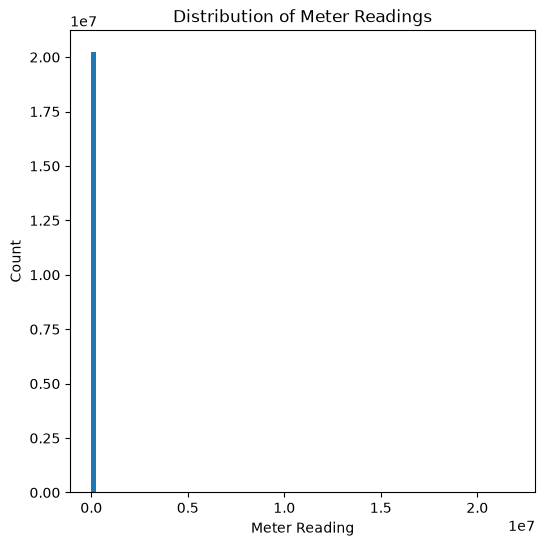

In [27]:
fig_1, ax_1 = plt.subplots(1,1,figsize=(6,6))
ax_1.hist(train_dataset["meter_reading"], bins=100)
ax_1.set_title("Distribution of Meter Readings")
ax_1.set_xlabel("Meter Reading")
ax_1.set_ylabel("Count")

plt.show()

Видим, что таргет очень сильно смещён вправо. Посмотрим на распределение только до 99 пецентиля.

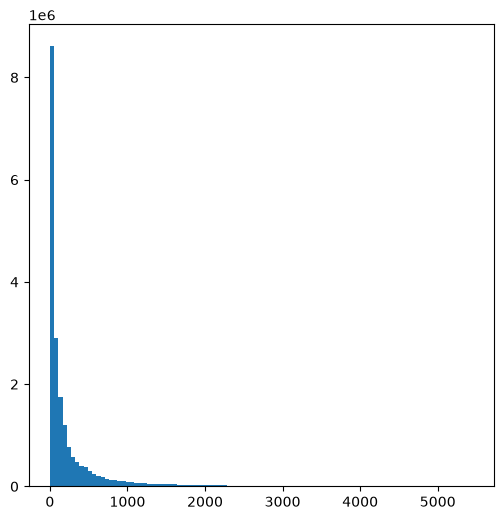

In [28]:
upper = train_dataset["meter_reading"].quantile(0.99)

fig_2, ax_2 = plt.subplots(1,1,figsize=(6,6))
ax_2.hist(train_dataset["meter_reading"][train_dataset["meter_reading"] <= upper], bins=100)

ax_1.set_title("Distribution of Meter Readings (up to 99th percentile)")
ax_1.set_xlabel("Meter Reading")
ax_1.set_ylabel("Count")

plt.show()

А также проверим распределение логарифма таргрета.

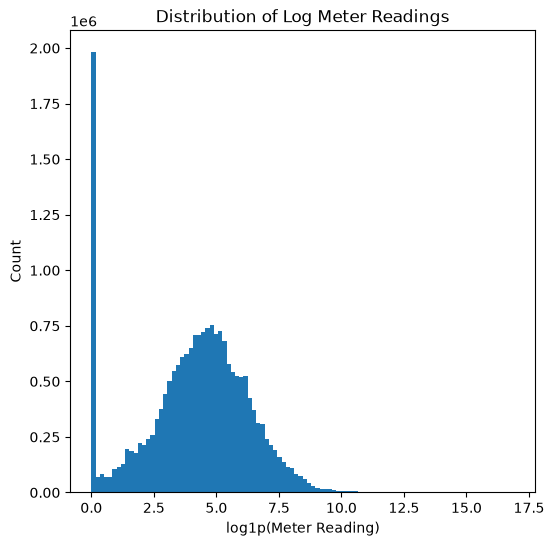

In [29]:
fig_3, ax_3 = plt.subplots(1,1,figsize=(6,6))
ax_3.hist(np.log1p(train_dataset["meter_reading"]), bins=100)

ax_3.set_title("Distribution of Log Meter Readings")
ax_3.set_xlabel("log1p(Meter Reading)")
ax_3.set_ylabel("Count")

plt.show()

Поэтому есть смысл использовать y = np.log1p(meter_reading) для сжатия больших значений, уменьшения влияния экстремальных наблюдений на ошибку. Что эквиваленто использование RMSLE метрики на исходном таргете.

## 6.2 Consumption Patterns

### По типу счётчика

Посмотрим на медиану/среднее по типу счётчика

In [30]:
readings_by_meter_type = train_dataset.groupby('meter')['meter_reading'].agg(['median', 'mean'])
display(readings_by_meter_type)

,median,mean
meter,,
0,62.831902,170.825638
1,120.487000,633.363892
2,257.812012,13882.187500
3,39.623699,385.866791


Использование только среднего значения может быть нерепрезентативным, а медиана лучше отражает типичный уровень потребления внутри группы

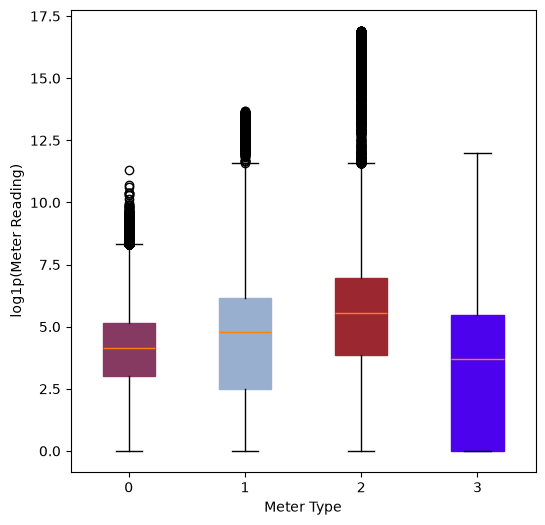

In [31]:
meter_types = sorted(train_dataset['meter'].unique())

readings_by_meter_type_list = [
    np.log1p(
    train_dataset[train_dataset['meter'] == meter]['meter_reading']
    )
    for meter in meter_types
]

fig_4, ax_4 = plt.subplots(1,1,figsize=(6,6))
box_1 = ax_4.boxplot(readings_by_meter_type_list, patch_artist=True)

for patch in box_1['boxes']:
    patch.set_color(np.random.rand(3))

ax_4.set_xlabel("Meter Type")
ax_4.set_ylabel("log1p(Meter Reading)")
ax_4.set_xticks(np.arange(1, len(meter_types)+1))
ax_4.set_xticklabels(meter_types)

plt.show()

Распределения log1p(meter_reading) заметно различаются между типами счётчиков. Это показывает, что тип счётчика является важным признаком.

### По назначению здания

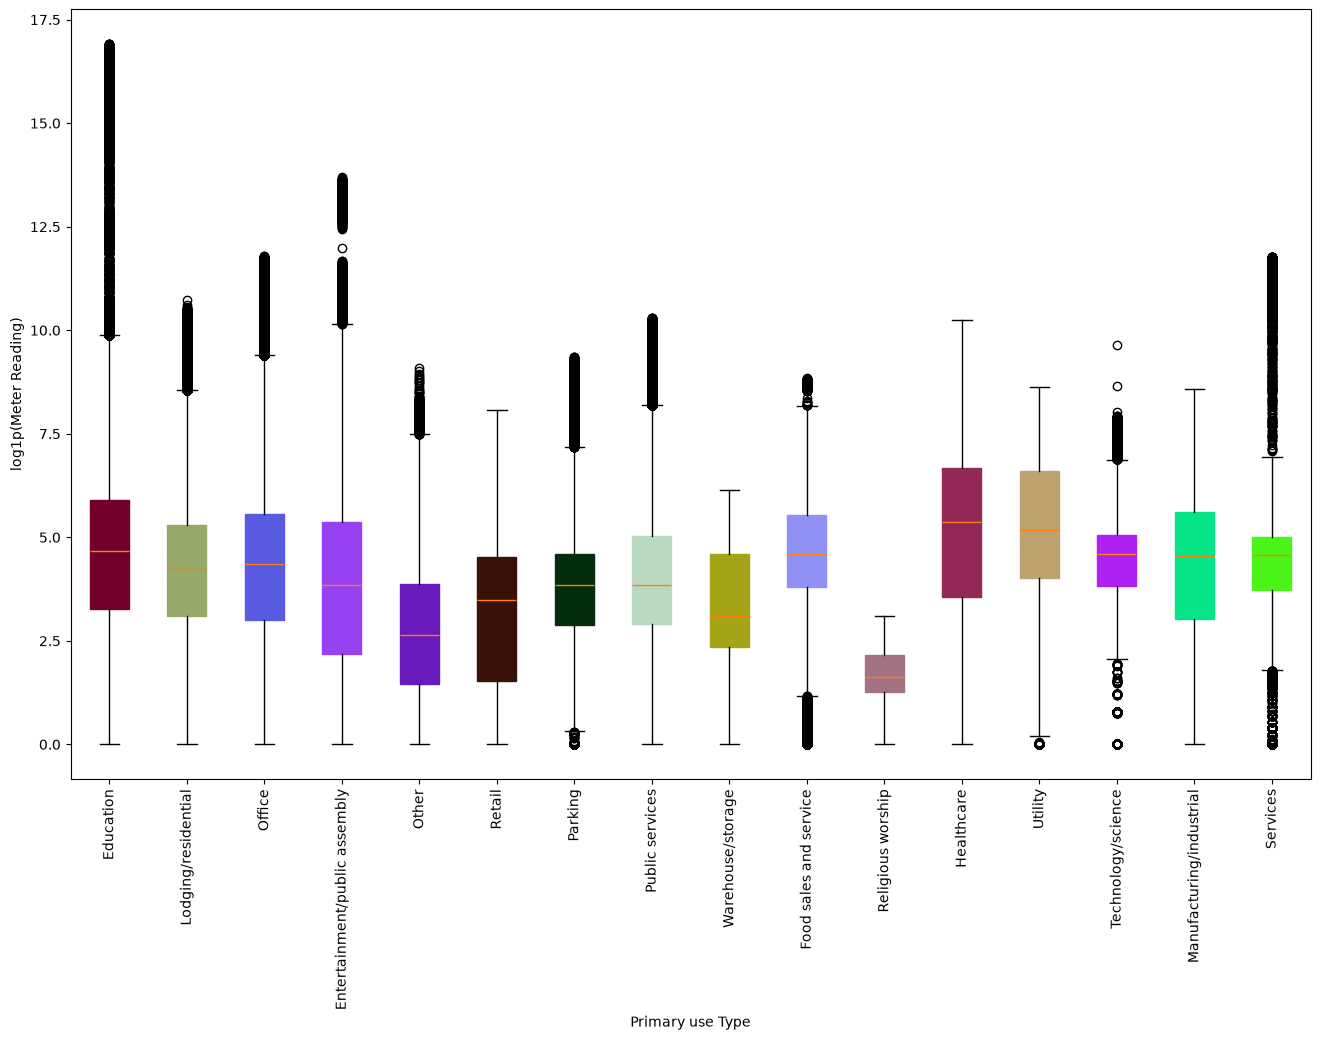

In [32]:
primary_use_types = train_dataset['primary_use'].unique()

readings_by_primary_use_types = [
    np.log1p(
        train_dataset[train_dataset['primary_use'] == use]['meter_reading']
    )
    for use in primary_use_types
]

fig_5,ax_5 = plt.subplots(1,1,figsize=(16,10))
box_2 = ax_5.boxplot(readings_by_primary_use_types, patch_artist=True)

for patch in box_2['boxes']:
    patch.set_color(np.random.rand(3))

ax_5.set_xlabel("Primary use Type")
ax_5.set_ylabel("log1p(Meter Reading)")
ax_5.set_xticks(np.arange(1, len(primary_use_types)+1))
ax_5.set_xticklabels(primary_use_types, rotation=90)

plt.show()

Наиболее высокие медианные значения наблюдаются у категорий Healthcare и Utility, тогда как Religious worship и Other имеют существенно более низкий типичный уровень потребления.
При этом для ряда категорий, например Education, Entertainment/public assembly и Services, сохраняется большое количество верхних выбросов
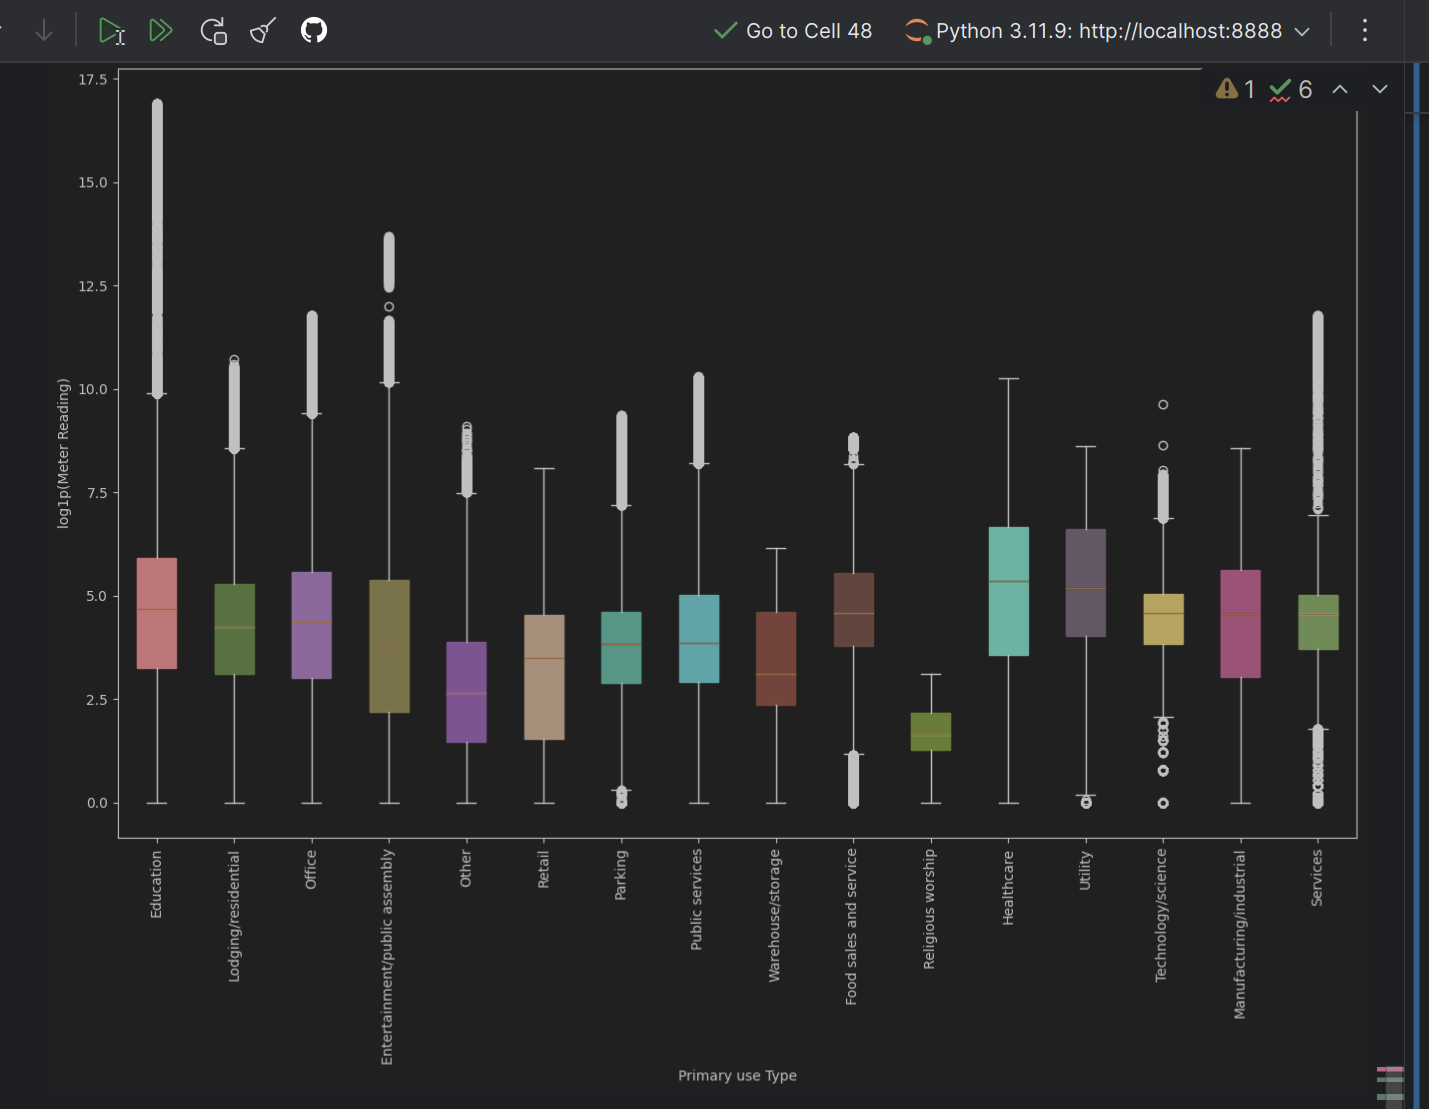

### По размеру здания

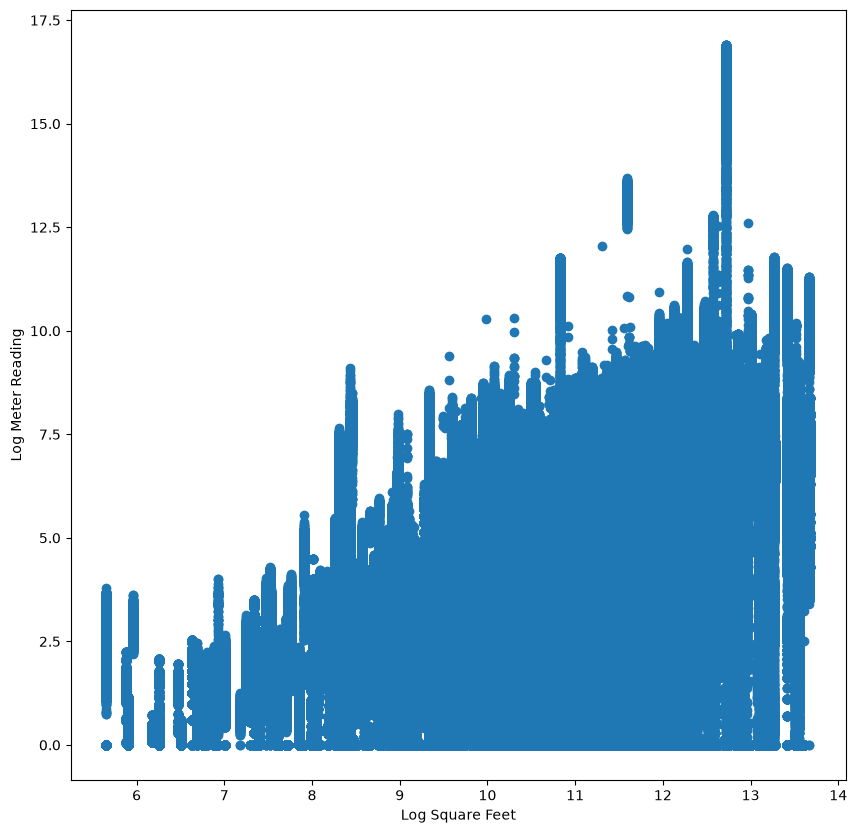

In [33]:
log_square_feet = np.log1p(train_dataset['square_feet'])
log_meter_reading = np.log1p(train_dataset['meter_reading'])

fig_6, ax_6 = plt.subplots(1,1,figsize=(10,10))
ax_6.scatter(log_square_feet, log_meter_reading)

ax_6.set_xlabel("Log Square Feet")
ax_6.set_ylabel("Log Meter Reading")

plt.show()

Более крупные здания в среднем имеют более высокое энергопотребление. При этом разброс значений остаётся большим - для зданий одинаковой площади meter_reading может сильно различаться.

Вертикальные группы точек возникают из-за повторных почасовых измерений для одних и тех же зданий: площадь здания постоянна, тогда как потребление меняется во времени.

### По количеству этажей

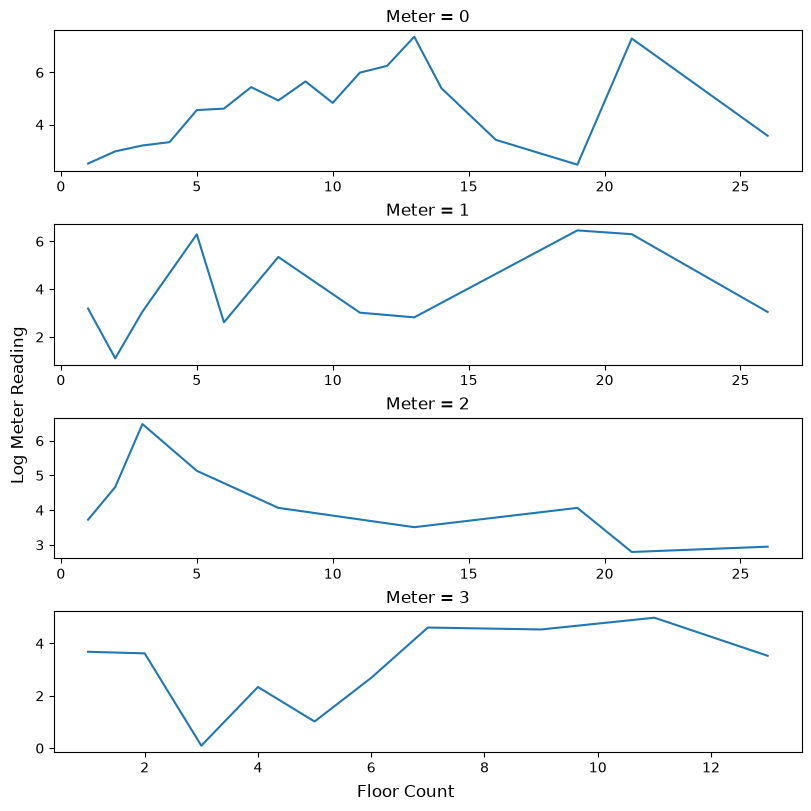

In [34]:
fig_12, ax_12 = plt.subplots(len(meter_types),1,figsize=(8,8), constrained_layout=True)

for i in range(len(meter_types)):
    floor_relation= train_dataset[train_dataset['meter'] == meter_types[i]].assign(
        log_meter_reading=log_meter_reading
    ).groupby('floor_count')['log_meter_reading'].mean()

    ax_12[i].plot(floor_relation.index, floor_relation)
    ax_12[i].set_title(f"Meter = {meter_types[i]}")

fig_12.supxlabel("Floor Count")
fig_12.supylabel("Log Meter Reading")

plt.show()

По графику не видно явной монотонной зависимости между количеством этажей и энергопотреблением. Характер связи заметно различается для разных типов счётчиков.

Особенно сильные колебания для некоторых значений floor_count могут быть связаны с тем, что зданий с такой этажностью мало.

### По времени суток

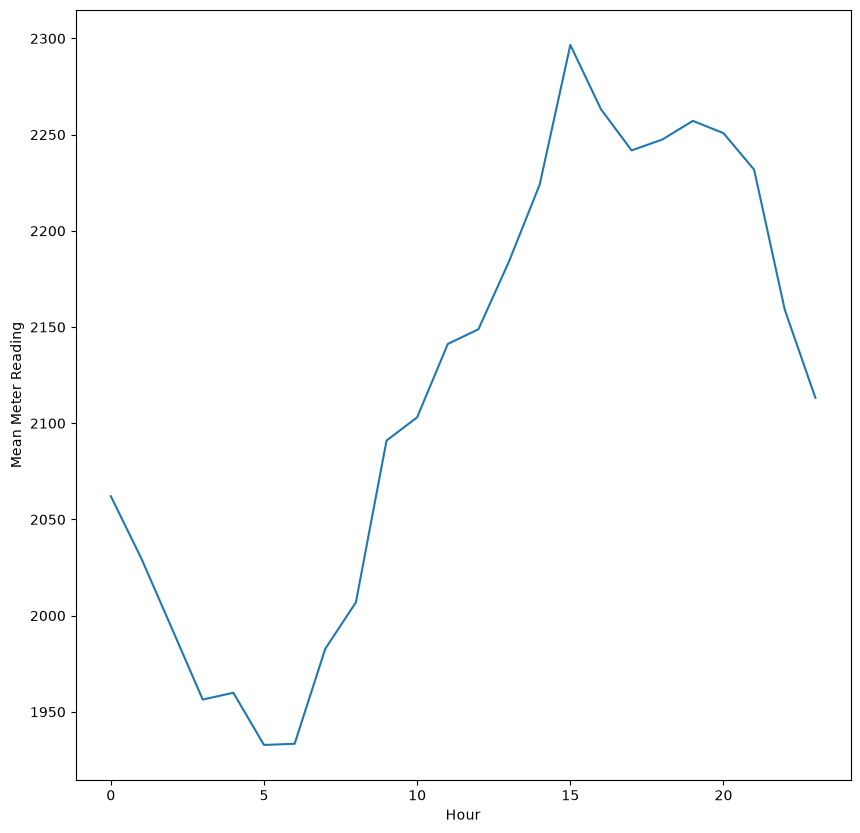

In [35]:
hourly_mean = train_dataset.assign(
    hour = train_dataset["timestamp"].dt.hour,
    log_meter_Reading = log_square_feet,
).groupby('hour')['meter_reading'].mean()

fig_7, ax_7 = plt.subplots(1,1, figsize=(10,10))
ax_7.plot(hourly_mean.index, hourly_mean)

ax_7.set_xlabel("Hour")
ax_7.set_ylabel("Mean Meter Reading")

plt.show()

Ожидаемый результат, посмотрим для каждого primary_use отдельно.

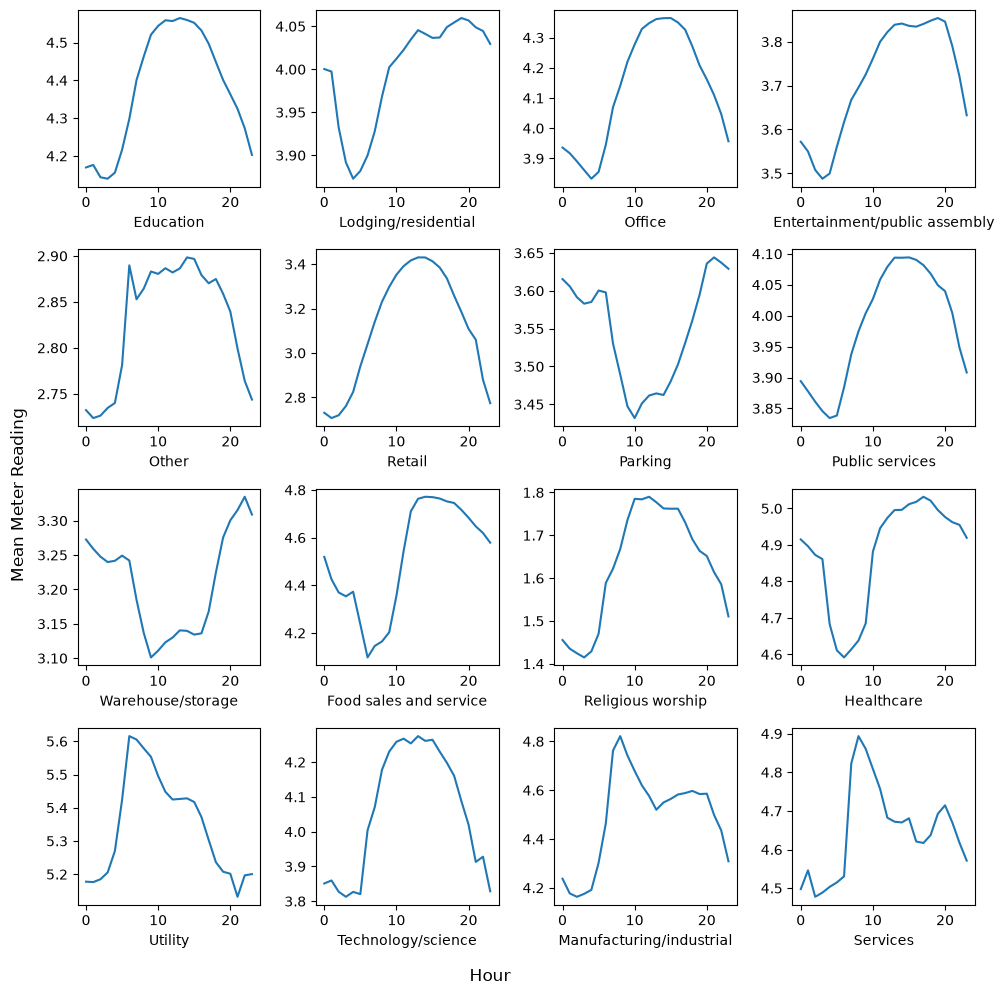

In [36]:
num_col_row = int(np.ceil(np.sqrt(len(primary_use_types))))
fig_8,ax_8 = plt.subplots(num_col_row,num_col_row,figsize=(10,10))

for i in range(len(primary_use_types)):
     hourly_mean = train_dataset[train_dataset['primary_use'] == primary_use_types[i]].assign(
         hour = train_dataset['timestamp'].dt.hour,
         meter_reading = log_meter_reading
     ).groupby('hour')['meter_reading'].mean()
     row = i // num_col_row
     col = i % num_col_row
     ax_8[row, col].plot(hourly_mean.index, hourly_mean)

     ax_8[row, col].set_xlabel(primary_use_types[i])


fig_8.supxlabel("Hour")
fig_8.supylabel("Mean Meter Reading")
fig_8.tight_layout()
plt.show()

Различия суточных профилей между категориями primary_use указывает на возможное взаимодействие между назначением здания и временем суток

Так же наличие выраженной суточной зависимости обосновывает добавление временных признаков hour и/или его циклического представления hour_sin / hour_cos .

### 6.3 Weather

Посмотрим корреляционные матрицы для погодных признаков отдельно для каждого типа meter, т. к. погода может по-разному влиять на различные траты услуг жку.

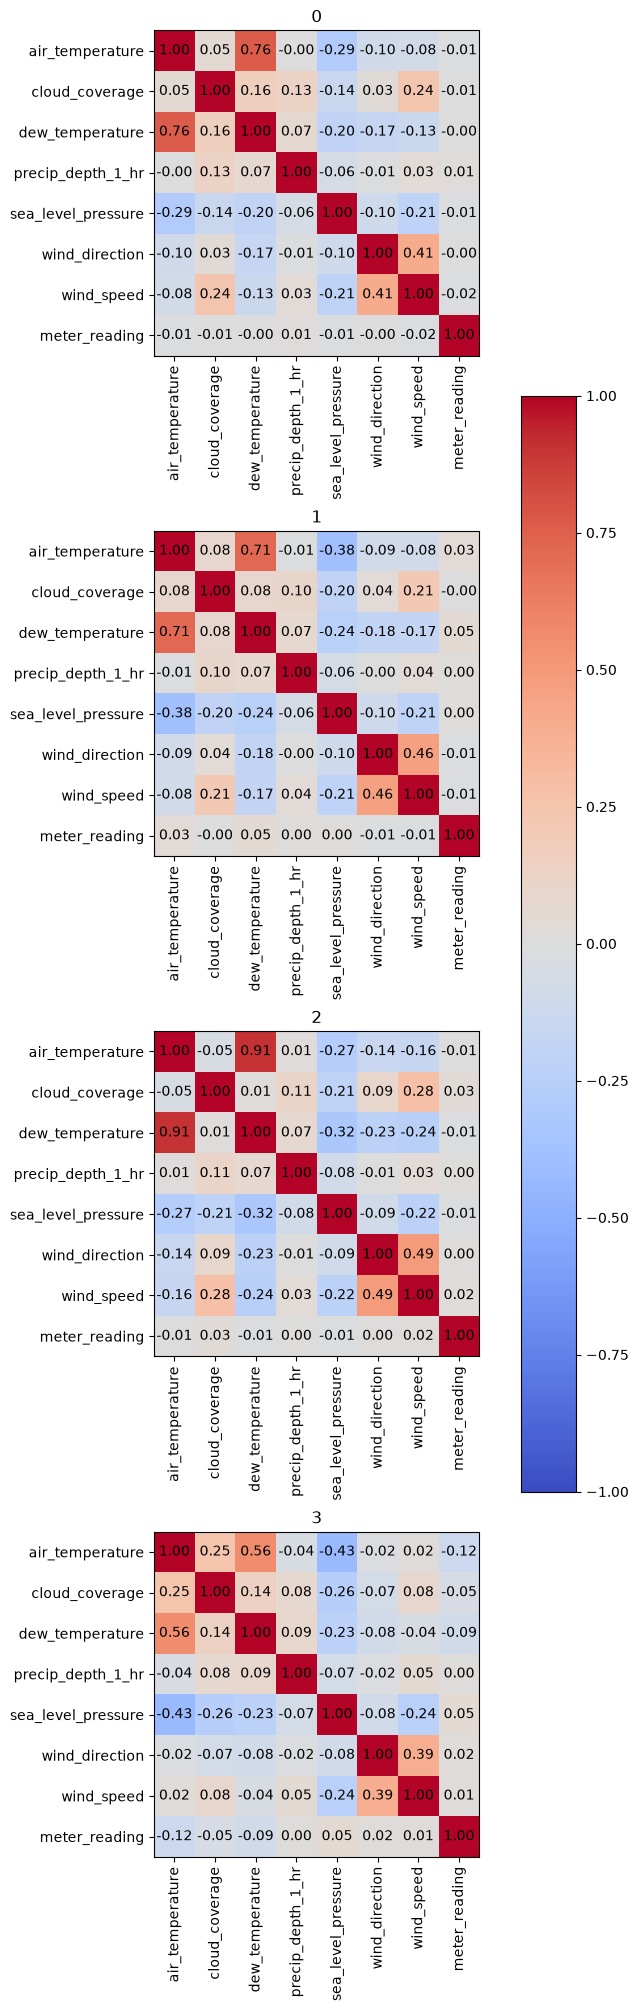

In [37]:
weather_features = weather_train.columns.drop(['site_id', 'timestamp']).tolist()
weather_features.append('meter_reading')

fig_9, ax_9 = plt.subplots(len(meter_types), 1, figsize=(10,20),constrained_layout=True)

for i in range(len(meter_types)):
    corr_mat = train_dataset[train_dataset['meter'] == meter_types[i]][weather_features].corr()

    img = ax_9[i].imshow(corr_mat, cmap='coolwarm', vmin=-1,vmax=1)
    for j in range(corr_mat.shape[0]):
        for k in range(corr_mat.shape[1]):
            ax_9[i].text(j,k, f"{corr_mat.iloc[k,j]:.2f}", ha='center', va='center')

    ax_9[i].set_title(meter_types[i])
    ax_9[i].set_xticks(np.arange(len(weather_features)))
    ax_9[i].set_yticks(np.arange(len(weather_features)))
    ax_9[i].set_xticklabels(weather_features, rotation=90)
    ax_9[i].set_yticklabels(weather_features)

fig_9.colorbar(img, ax=ax_9, shrink=0.6)
plt.show()

Для всех типов счётчиков линейная корреляция погодных признаков с meter_reading довольно слабая: абсолютные значения коэффициентов корреляции с таргетом в основном близки к нулю. Наиболее заметная связь наблюдается для meter = 3.

При этом слабая корреляция не означает отсутствия влияния погоды на энергопотребление. Связь может быть нелинейной и зависеть от типа счётчика, назначения здания, времени суток и сезона.

In [38]:
def weather_target_relation(
    df,
    feature,
    bins=30
):
    result = (
        df
        .assign(
            feature_bin=pd.cut(
                df[feature],
                bins=bins
            ),
            log_meter_reading=np.log1p(
                df["meter_reading"]
            )
        )
        .groupby(
            ["meter", "feature_bin"],
            observed=True
        )["log_meter_reading"]
        .mean()
        .reset_index()
    )

    result["feature_value"] = (
        result["feature_bin"]
        .apply(lambda interval: interval.mid)
        .astype(float)
    )

    return result

In [39]:
air_temp_relation = weather_target_relation(
    train_dataset,
    "air_temperature"
)

dew_temp_relation = weather_target_relation(
    train_dataset,
    "dew_temperature"
)

wind_relation = weather_target_relation(
    train_dataset,
    "wind_speed"
)

In [40]:
def plot_weather_relation(relation_df, feature_name, ax):
    for meter in meter_types:
        meter_data = relation_df[
            relation_df["meter"] == meter
        ]

        ax.plot(
            meter_data["feature_value"],
            meter_data["log_meter_reading"],
            marker="o",
            markersize=3,
            label=f"Meter {meter}"
        )

    ax.set_xlabel(feature_name)
    ax.set_ylabel("Mean log1p(Meter Reading)")
    ax.legend()
    ax.grid(alpha=0.3)

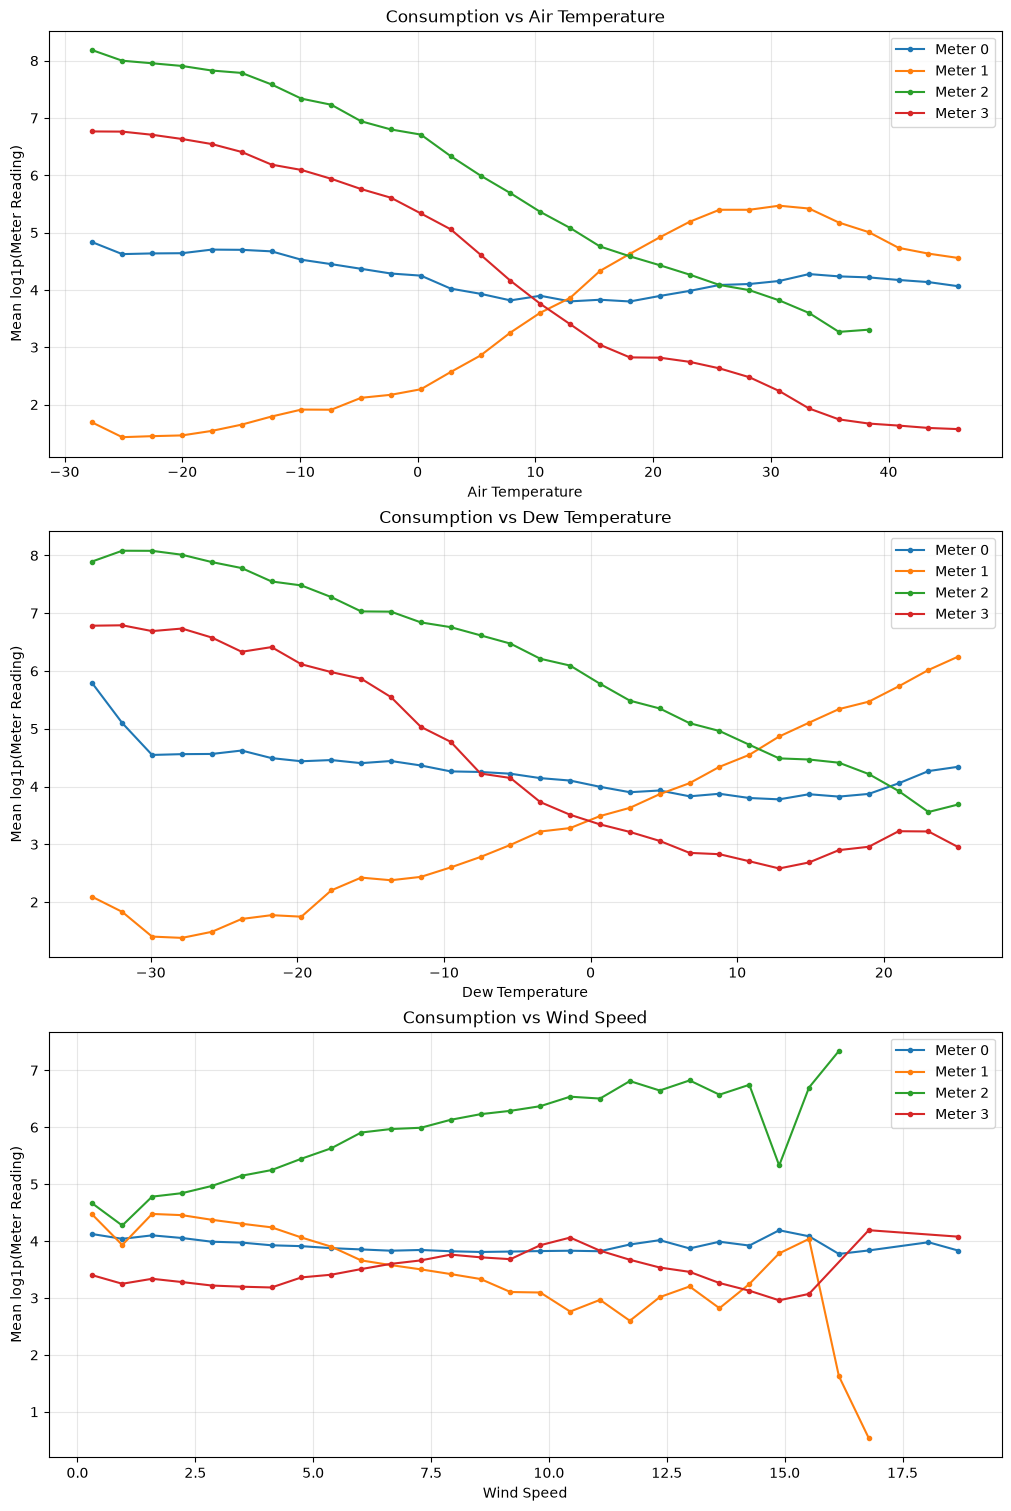

In [41]:
fig_10, ax_10 = plt.subplots(
    3, 1,
    figsize=(10, 15),
    constrained_layout=True
)

plot_weather_relation(
    air_temp_relation,
    "Air Temperature",
    ax_10[0]
)
ax_10[0].set_title("Consumption vs Air Temperature")

plot_weather_relation(
    dew_temp_relation,
    "Dew Temperature",
    ax_10[1]
)
ax_10[1].set_title("Consumption vs Dew Temperature")

plot_weather_relation(
    wind_relation,
    "Wind Speed",
    ax_10[2]
)
ax_10[2].set_title("Consumption vs Wind Speed")

plt.show()

Графики показывают выраженные нелинейные зависимости, причём их характер существенно различается между типами счётчиков. Только для meter = 0 связь с температурой выражена достаточно слабо.

Зависимость от dew_temperature во многом повторяет характер зависимости от air_temperature, что согласуется с высокой корреляцией этих двух погодных признаков.

Посмотрим теперь на precip_depth_1_hr

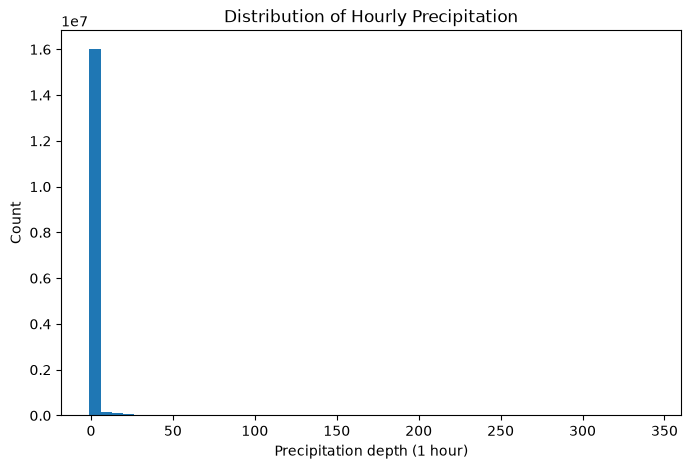

In [43]:
fig_11, ax_11 = plt.subplots(figsize=(8, 5))

ax_11.hist(
    train_dataset["precip_depth_1_hr"].dropna(),
    bins=50
)

ax_11.set_xlabel("Precipitation depth (1 hour)")
ax_11.set_ylabel("Count")
ax_11.set_title("Distribution of Hourly Precipitation")

plt.show()

Распределение сильно несбалансировано. Разделим наблюдения на группы, чтобы уменьшить влияния редких экстремальных значений.

In [44]:
non_zero_precip = train_dataset.loc[
    train_dataset["precip_depth_1_hr"] > 0,
    "precip_depth_1_hr"
]

q1 = non_zero_precip.quantile(1 / 3)
q2 = non_zero_precip.quantile(2 / 3)

In [45]:
precip_relation = (
    train_dataset
    .assign(
        precip_group=lambda df: pd.cut(
            df["precip_depth_1_hr"],
            bins=[-np.inf, 0, q1, q2, np.inf],
            labels=[
                "No precipitation",
                "Low",
                "Medium",
                "High"
            ]
        ),
        log_meter_reading=lambda df: np.log1p(
            df["meter_reading"]
        )
    )
    .groupby(
        ["meter", "precip_group"],
        observed=True
    )["log_meter_reading"]
    .mean()
    .reset_index()
)

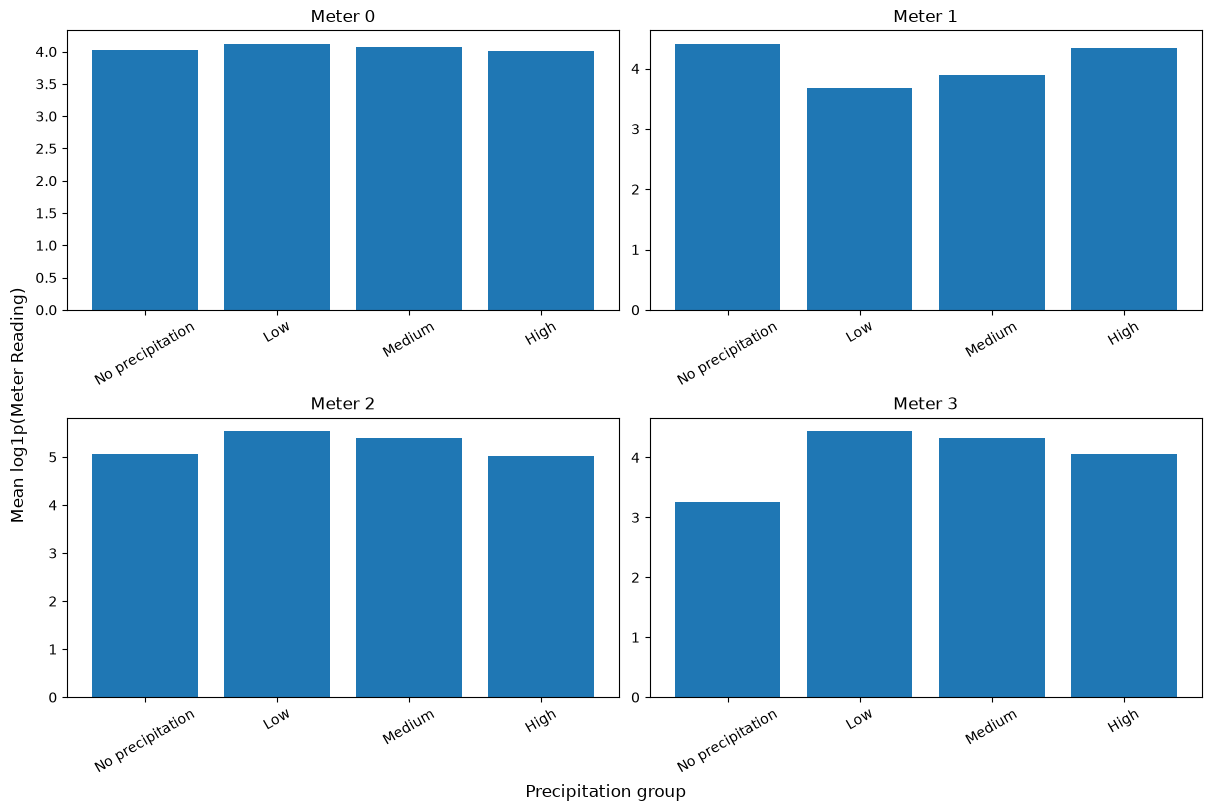

In [46]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    constrained_layout=True
)

for ax, meter in zip(
    axes.flat,
    meter_types
):
    data = precip_relation[
        precip_relation["meter"] == meter
    ]

    ax.bar(
        data["precip_group"].astype(str),
        data["log_meter_reading"]
    )

    ax.set_title(f"Meter {meter}")
    ax.tick_params(axis="x", rotation=30)

fig.supxlabel("Precipitation group")
fig.supylabel("Mean log1p(Meter Reading)")

plt.show()

Явного монотонного тренда "чем сильнее осадки, тем выше/ниже потребление" не наблюдается. Но значения по счётчикам отличаются, поэтому признак может быть полезен.

# 7. Evaluate

In [86]:
train_sorted = (
    train_dataset
    .sort_values("timestamp")
    .reset_index(drop=True)
)

X = train_sorted.drop(
    columns=[
        "meter_reading",
        "timestamp"
    ]
)

y = np.log1p(
    train_sorted["meter_reading"]
)

timestamps = np.sort(
    train_sorted["timestamp"].unique()
)

tscv = TimeSeriesSplit(
    n_splits=N_splits
)

In [87]:
row_timestamps = train_sorted["timestamp"].to_numpy()

cv_folds = []

for train_time_idx, valid_time_idx in tscv.split(timestamps):

    first_train_time = timestamps[
        train_time_idx[0]
    ]

    last_train_time = timestamps[
        train_time_idx[-1]
    ]

    first_valid_time = timestamps[
        valid_time_idx[0]
    ]

    last_valid_time = timestamps[
        valid_time_idx[-1]
    ]


    train_start = np.searchsorted(
        row_timestamps,
        first_train_time,
        side="left"
    )

    train_end = np.searchsorted(
        row_timestamps,
        last_train_time,
        side="right"
    )

    valid_start = np.searchsorted(
        row_timestamps,
        first_valid_time,
        side="left"
    )

    valid_end = np.searchsorted(
        row_timestamps,
        last_valid_time,
        side="right"
    )


    cv_folds.append({
        "train_start": train_start,
        "train_end": train_end,
        "valid_start": valid_start,
        "valid_end": valid_end
    })

In [77]:
categorical_features = [
    "primary_use"
]

numeric_features = [
    column
    for column in X.columns
    if column not in categorical_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['building_id', 'meter', 'site_id', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']

Categorical features:
['primary_use']


In [78]:
def evaluate_model(
    model,
    X_train,
    y_train,
    X_valid,
    y_valid
):
    model = clone(model)

    start_time = time.time()

    model.fit(
        X_train,
        y_train
    )

    train_time = time.time() - start_time


    start_time = time.time()

    y_pred = model.predict(
        X_valid
    )

    predict_time = time.time() - start_time

    rmsle = np.sqrt(
        mean_squared_error(
            y_valid,
            y_pred
        )
    )


    return {
        "model": model,
        "rmsle": rmsle,
        "train_time": train_time,
        "predict_time": predict_time
    }

# 8. Baseline

In [79]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            make_pipeline(
                SimpleImputer(
                    strategy="median"
                ),
                StandardScaler()
            ),
            numeric_features
        ),

        (
            "cat",
            make_pipeline(
                SimpleImputer(
                    strategy="most_frequent"
                ),
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            ),
            categorical_features
        )
    ]
)

In [80]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(
                strategy="median"
            ),
            numeric_features
        ),

        (
            "cat",
            make_pipeline(
                SimpleImputer(
                    strategy="most_frequent"
                ),
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            ),
            categorical_features
        )
    ]
)

In [89]:
baseline_models = {
    # Naive
    "Dummy": DummyRegressor(
        strategy="mean"
    ),


    # Linear
    "Ridge": make_pipeline(
        linear_preprocessor,

        Ridge(
            alpha=0.1
        )
    ),

    "SGD": make_pipeline(
        linear_preprocessor,

        SGDRegressor(
            loss="squared_error",
            penalty="l2",
            alpha=0.0001,
            max_iter=10000,
            random_state=SEED
        )
    ),


    # Tree-based
    "DecisionTree": make_pipeline(
        tree_preprocessor,

        DecisionTreeRegressor(
            max_depth=12,
            min_samples_leaf=20,
            random_state=SEED
        )
    ),

    # Boosting
    "XGBoost": make_pipeline(
        tree_preprocessor,

        XGBRegressor(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=8,
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED
        )
    ),


    "LightGBM": make_pipeline(
        tree_preprocessor,

        LGBMRegressor(
            n_estimators=300,
            learning_rate=0.1,
            num_leaves=63,
            n_jobs=-1,
            random_state=SEED,
            verbosity=-1
        )
    ),


    "CatBoost": make_pipeline(
        tree_preprocessor,

        CatBoostRegressor(
            iterations=500,
            depth=8,
            learning_rate=0.05,
            loss_function="RMSE",
            random_seed=SEED,
            verbose=False,
            thread_count=-1
        )
    )
}

Поскольку наблюдения имеют временную структуру, случайное перемешивание данных при кросс-валидации может привести к утечке информации из будущего в прошлое. Поэтому для оценки baseline-моделей используется временная кросс-валидация на основе `TimeSeriesSplit`.

Разбиение выполняется по уникальным значениям `timestamp`, а не непосредственно по строкам датасета. Это необходимо, поскольку одному моменту времени соответствует множество наблюдений для разных зданий и типов счётчиков. Такой подход гарантирует, что все наблюдения одного временного момента полностью относятся либо к обучающей, либо к валидационной части.

На каждом следующем фолде обучающая выборка расширяется за счёт более поздних наблюдений, а валидация всегда располагается строго после неё по времени. Таким образом, схема оценки приближена к реальному сценарию: модель обучается на исторических данных и предсказывает потребление энергии для будущего периода.

In [269]:
cv_results = []
trained_baseline_models = {}

best_baseline_name = None
best_baseline_score = np.inf


for name, model in baseline_models.items():

    print(f"\n{'=' * 60}")
    print(f"Model: {name}")
    print(f"{'=' * 60}")

    model_start_time = time.perf_counter()

    fold_scores = []
    fold_train_times = []
    fold_predict_times = []

    try:

        for fold, split in enumerate(
            cv_folds,
            start=1
        ):

            print(
                f"\nFold {fold}/{N_splits}"
            )

            X_train = X.iloc[
                split["train_start"]:
                split["train_end"]
            ]

            X_valid = X.iloc[
                split["valid_start"]:
                split["valid_end"]
            ]

            y_train = y.iloc[
                split["train_start"]:
                split["train_end"]
            ]

            y_valid = y.iloc[
                split["valid_start"]:
                split["valid_end"]
            ]

            result = evaluate_model(
                model,
                X_train,
                y_train,
                X_valid,
                y_valid
            )

            # Сохраняем модель последнего временного фолда
            if fold == N_splits:
                last_fold_model = result["model"]

            fold_scores.append(
                result["rmsle"]
            )

            fold_train_times.append(
                result["train_time"]
            )

            fold_predict_times.append(
                result["predict_time"]
            )

            print(
                f"RMSLE: "
                f"{result['rmsle']:.5f}"
            )

            print(
                f"Train time: "
                f"{result['train_time']:.2f} s"
            )

            print(
                f"Predict time: "
                f"{result['predict_time']:.2f} s"
            )

        wall_time = (
            time.perf_counter()
            - model_start_time
        )

        mean_rmsle = float(
            np.mean(fold_scores)
        )

        std_rmsle = float(
            np.std(fold_scores)
        )

        if name == "Dummy":
            trained_baseline_models[
                "Dummy"
            ] = last_fold_model

        elif mean_rmsle < best_baseline_score:
            if best_baseline_name is not None:
                trained_baseline_models.pop(
                    best_baseline_name,
                    None
                )

            best_baseline_name = name
            best_baseline_score = mean_rmsle

            trained_baseline_models[
                best_baseline_name
            ] = last_fold_model

        cv_results.append({
            "Model": name,
            "RMSLE Mean": mean_rmsle,
            "RMSLE Std": std_rmsle,
            "Train Time Mean (s)": np.mean(
                fold_train_times
            ),
            "Predict Time Mean (s)": np.mean(
                fold_predict_times
            ),
            "Total Fit/Predict Time (s)": (
                np.sum(fold_train_times)
                + np.sum(fold_predict_times)
            ),
            "Wall Time (s)": wall_time,
            "Status": "Success"
        })

        print(
            f"\n{name}: "
            f"{mean_rmsle:.5f}"
            f" ± "
            f"{std_rmsle:.5f}"
        )

        print(
            f"Total wall time: "
            f"{wall_time:.2f} s"
        )

    except Exception as error:

        wall_time = (
            time.perf_counter()
            - model_start_time
        )

        cv_results.append({
            "Model": name,
            "RMSLE Mean": np.nan,
            "RMSLE Std": np.nan,
            "Train Time Mean (s)": np.nan,
            "Predict Time Mean (s)": np.nan,
            "Total Fit/Predict Time (s)": np.nan,
            "Wall Time (s)": wall_time,
            "Status": str(error)
        })

        print(
            f"\nError: {error}"
        )


print("\nСохранённые обученные модели:")

for model_name in trained_baseline_models:
    print(model_name)

print(
    f"\nЛучшая baseline-модель: "
    f"{best_baseline_name}"
)

print(
    f"Mean CV RMSLE: "
    f"{best_baseline_score:.5f}"
)


Model: Dummy

Fold 1/3
RMSLE: 2.13641
Train time: 0.19 s
Predict time: 0.00 s

Fold 2/3
RMSLE: 2.09547
Train time: 0.01 s
Predict time: 0.01 s

Fold 3/3
RMSLE: 2.10340
Train time: 0.02 s
Predict time: 0.00 s

Dummy: 2.11176 ± 0.01773
Total wall time: 0.93 s

Model: Ridge

Fold 1/3
RMSLE: 2.03325
Train time: 17.89 s
Predict time: 4.14 s

Fold 2/3
RMSLE: 1.96573
Train time: 26.84 s
Predict time: 6.23 s

Fold 3/3
RMSLE: 1.93475
Train time: 57.11 s
Predict time: 4.06 s

Ridge: 1.97791 ± 0.04113
Total wall time: 116.57 s

Model: SGD

Fold 1/3
RMSLE: 2.04716
Train time: 20.08 s
Predict time: 3.61 s

Fold 2/3
RMSLE: 1.95340
Train time: 42.55 s
Predict time: 3.41 s

Fold 3/3
RMSLE: 1.93372
Train time: 72.30 s
Predict time: 3.43 s

SGD: 1.97809 ± 0.04949
Total wall time: 145.59 s

Model: DecisionTree

Fold 1/3
RMSLE: 1.63760
Train time: 42.65 s
Predict time: 3.54 s

Fold 2/3
RMSLE: 1.44547
Train time: 100.85 s
Predict time: 3.63 s

Fold 3/3
RMSLE: 1.77696
Train time: 159.55 s
Predict time: 3.6

In [270]:
results_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        "RMSLE Mean"
    )
    .reset_index(drop=True)
)

display(results_df)

,Model,RMSLE Mean,RMSLE Std,Train Time Mean (s),Predict Time Mean (s),Total Fit/Predict Time (s),Wall Time (s),Status
0,XGBoost,1.377749,0.146762,127.260884,8.006533,405.802252,405.944082,Success
1,LightGBM,1.387257,0.142196,64.661923,25.482011,270.431803,270.615985,Success
2,CatBoost,1.499972,0.099095,405.371352,5.038519,1231.229613,1231.676723,Success
3,DecisionTree,1.620007,0.135902,101.015685,3.604470,313.860467,314.066426,Success
4,Ridge,1.977911,0.041125,33.945974,4.807368,116.260026,116.571960,Success
5,SGD,1.978091,0.049494,44.976377,3.484869,145.383740,145.594096,Success
6,Dummy,2.111761,0.017731,0.072660,0.004018,0.230034,0.927986,Success


Среди сильных моделей LightGBM обеспечивает лучший компромисс между качеством и временем обучения: его результат близок к XGBoost, однако среднее время обучения примерно в два раза меньше. XGBoost при этом показывает минимальный RMSLE среди протестированных baseline-моделей.

In [271]:
def save_baseline_submission(
    model_name,
    output_path,
    chunk_size=500_000
):
    model = trained_baseline_models[
        model_name
    ]

    assert (
        test_dataset["row_id"]
        .is_monotonic_increasing
    )

    for start in range(
        0,
        len(test_dataset),
        chunk_size
    ):
        end = min(
            start + chunk_size,
            len(test_dataset)
        )

        chunk = test_dataset.iloc[
            start:end
        ]

        # Модель предсказывает log1p(meter_reading)
        log_prediction = model.predict(
            chunk[X.columns]
        )

        # Возвращаемся к исходному meter_reading
        prediction = np.expm1(
            log_prediction
        )

        prediction = np.clip(
            prediction,
            0,
            None
        ).astype(np.float32)

        chunk_submission = pd.DataFrame({
            "row_id": (
                chunk["row_id"]
                .to_numpy()
            ),
            "meter_reading": prediction
        })

        chunk_submission.to_csv(
            output_path,
            mode=(
                "w"
                if start == 0
                else "a"
            ),
            header=(start == 0),
            index=False
        )

        print(
            f"{model_name}: "
            f"{end:,}/"
            f"{len(test_dataset):,}"
        )

    print(
        f"Сохранён: {output_path}"
    )


save_baseline_submission(
    model_name="Dummy",
    output_path="submission_dummy.csv"
)

best_output_path = (
    f"submission_"
    f"{best_baseline_name.lower()}"
    f"_baseline.csv"
)

save_baseline_submission(
    model_name=best_baseline_name,
    output_path=best_output_path
)

Dummy: 500,000/41,697,600
Dummy: 1,000,000/41,697,600
Dummy: 1,500,000/41,697,600
Dummy: 2,000,000/41,697,600
Dummy: 2,500,000/41,697,600
Dummy: 3,000,000/41,697,600
Dummy: 3,500,000/41,697,600
Dummy: 4,000,000/41,697,600
Dummy: 4,500,000/41,697,600
Dummy: 5,000,000/41,697,600
Dummy: 5,500,000/41,697,600
Dummy: 6,000,000/41,697,600
Dummy: 6,500,000/41,697,600
Dummy: 7,000,000/41,697,600
Dummy: 7,500,000/41,697,600
Dummy: 8,000,000/41,697,600
Dummy: 8,500,000/41,697,600
Dummy: 9,000,000/41,697,600
Dummy: 9,500,000/41,697,600
Dummy: 10,000,000/41,697,600
Dummy: 10,500,000/41,697,600
Dummy: 11,000,000/41,697,600
Dummy: 11,500,000/41,697,600
Dummy: 12,000,000/41,697,600
Dummy: 12,500,000/41,697,600
Dummy: 13,000,000/41,697,600
Dummy: 13,500,000/41,697,600
Dummy: 14,000,000/41,697,600
Dummy: 14,500,000/41,697,600
Dummy: 15,000,000/41,697,600
Dummy: 15,500,000/41,697,600
Dummy: 16,000,000/41,697,600
Dummy: 16,500,000/41,697,600
Dummy: 17,000,000/41,697,600
Dummy: 17,500,000/41,697,600
Dummy:

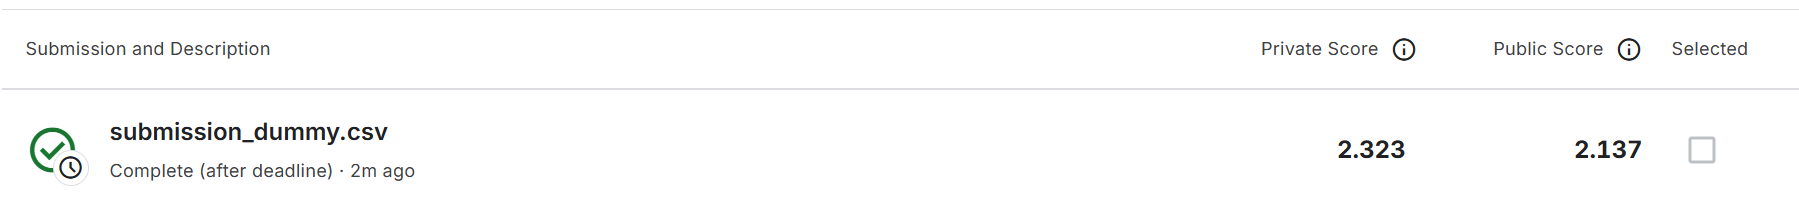

Private Score 2.323

Public Score 2.137

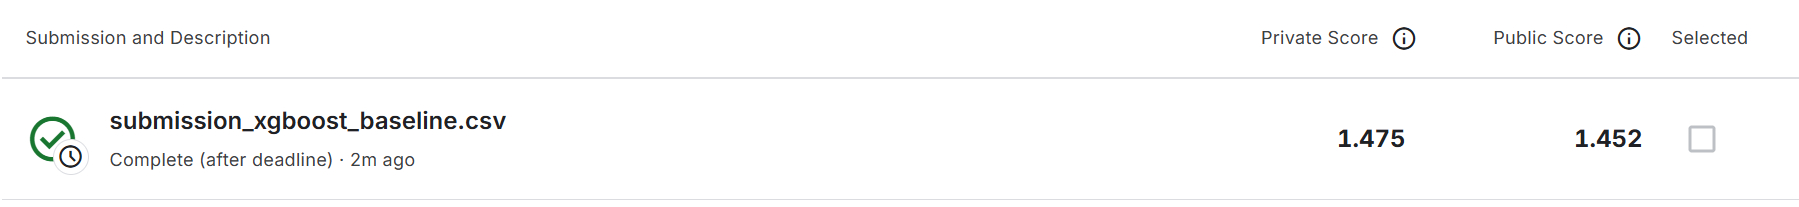

Private Score 1.475

Public Score 1.452

# 8. Missing values

In [94]:
def missing_values_summary(df):
    missing = df.isna().sum()

    result = pd.DataFrame({
        "Missing": missing,
        "Missing %": missing / len(df) * 100
    })

    return (
        result[result["Missing"] > 0]
        .sort_values(
            "Missing %",
            ascending=False
        )
    )


train_missing = missing_values_summary(
    train_dataset
)

test_missing = missing_values_summary(
    test_dataset
)

print("Train missing values:")
display(train_missing)

print("Test missing values:")
display(test_missing)

Train missing values:


,Missing,Missing %
floor_count,16709167,82.652772
year_built,12127645,59.990033
cloud_coverage,8825365,43.655131
precip_depth_1_hr,3749023,18.544739
wind_direction,1449048,7.167792
sea_level_pressure,1231669,6.092515
wind_speed,143676,0.710701
dew_temperature,100140,0.495348
air_temperature,96658,0.478124


Test missing values:


,Missing,Missing %
floor_count,34444320,82.605042
year_built,24598080,58.991597
cloud_coverage,19542180,46.866438
precip_depth_1_hr,7801563,18.709861
wind_direction,2978663,7.143488
sea_level_pressure,2516826,6.035901
wind_speed,302089,0.724476
dew_temperature,260799,0.625453
air_temperature,221901,0.532167


Используем следующую стратегию обработки пропусков:

1. Для Ridge, XGBoost, Decision Tree и MLP числовые признаки заполняются медианой, рассчитанной только на обучающей выборке. Медиана выбрана как более устойчивая к выбросам статистика.

2. Категориальные признаки заполняются наиболее частым значением.

3. LightGBM поддерживает пропущенные значения напрямую, поэтому для него дополнительная импутация числовых признаков не выполняется.


Импутация выполняется после разделения данных на train и validation, поэтому статистики заполнения не используют информацию из validation.

# 9. Feature Engineering

## Weather Lag Features

Для температуры добавим значения из предыдущего, 24-го и 168-го предыдущего погодного наблюдения, что при регулярной почасовой сетке соответствует примерно одному часу, суткам и неделе.

Объединяем weather train/test, чтобы первые строки 2017 года могли использовать конец 2016 года:

In [157]:
weather_for_lags = (
    pd.concat(
        [
            weather_train[
                [
                    "site_id",
                    "timestamp",
                    "air_temperature"
                ]
            ],
            weather_test[
                [
                    "site_id",
                    "timestamp",
                    "air_temperature"
                ]
            ]
        ],
        ignore_index=True
    )
    .sort_values(
        ["site_id", "timestamp"]
    )
    .drop_duplicates(
        ["site_id", "timestamp"]
    )
    .reset_index(drop=True)
)

In [158]:
for lag in [1, 24, 168]:
    weather_for_lags[
        f"air_temperature_lag_{lag}"
    ] = (
        weather_for_lags
        .groupby("site_id")[
            "air_temperature"
        ]
        .shift(lag)
        .astype("float32")
    )


weather_for_lags[
    "air_temperature_rolling_24"
] = (
    weather_for_lags
    .groupby("site_id")[
        "air_temperature"
    ]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=24,
            min_periods=1
        )
        .mean()
    )
    .astype("float32")
)

In [161]:
lag_features = [
    "air_temperature_lag_1",
    "air_temperature_lag_24",
    "air_temperature_lag_168",
    "air_temperature_rolling_24"
]

weather_lags = weather_for_lags[
    [
        "site_id",
        "timestamp",
        *lag_features
    ]
]


train_dataset_lag = train_dataset.merge(
    weather_lags,
    on=[
        "site_id",
        "timestamp"
    ],
    how="left",
    validate="many_to_one"
)

test_dataset_lag = test_dataset.merge(
    weather_lags,
    on=[
        "site_id",
        "timestamp"
    ],
    how="left",
    validate="many_to_one"
)

## Temporal, Cyclical and etc features

`month` и `is_weekend` отражают календарную сезонность потребления.

Циклическое представление часа и дня недели позволяет учитывать близость конца и начала соответствующего периода.

`log_square_feet` уменьшает масштаб различий между зданиями разной площади.

`temp_dew_diff`, `heating_degree` и `cooling_degree` добавляют нелинейную информацию о погодных условиях, потенциально связанную с отоплением и охлаждением зданий.

Общая функция для train и test.

In [164]:
def create_features(df):
    df = df.copy()

    hour = df["timestamp"].dt.hour
    day_of_week = df["timestamp"].dt.dayofweek

    # 9.1 Temporal features
    df["month"] = (
        df["timestamp"]
        .dt.month
        .astype("uint8")
    )

    df["is_weekend"] = (
        day_of_week >= 5
    ).astype("uint8")


    # 9.2 Cyclical features
    df["hour_sin"] = np.sin(
        2 * np.pi * hour / 24
    ).astype("float32")

    df["hour_cos"] = np.cos(
        2 * np.pi * hour / 24
    ).astype("float32")


    df["day_of_week_sin"] = np.sin(
        2 * np.pi * day_of_week / 7
    ).astype("float32")

    df["day_of_week_cos"] = np.cos(
        2 * np.pi * day_of_week / 7
    ).astype("float32")


    # 9.3 Building features
    df["log_square_feet"] = np.log1p(
        df["square_feet"]
    ).astype("float32")


    # 9.4 Weather features
    df["temp_dew_diff"] = (
        df["air_temperature"]
        - df["dew_temperature"]
    ).astype("float32")


    df["heating_degree"] = (
        18 - df["air_temperature"]
    ).clip(lower=0).astype("float32")


    df["cooling_degree"] = (
        df["air_temperature"] - 18
    ).clip(lower=0).astype("float32")

    return df

In [165]:
train_features = create_features(
    train_dataset_lag
)

test_features = create_features(
    test_dataset_lag
)

In [166]:
engineered_features = [
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "log_square_feet",
    "temp_dew_diff",
    "heating_degree",
    "cooling_degree",

    "air_temperature_lag_1",
    "air_temperature_lag_24",
    "air_temperature_lag_168",
    "air_temperature_rolling_24"
]

display(
    train_features[
        engineered_features
    ].head()
)

,month,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,log_square_feet,temp_dew_diff,heating_degree,cooling_degree,air_temperature_lag_1,air_temperature_lag_24,air_temperature_lag_168,air_temperature_rolling_24
0,1,0,0.0,1.0,-0.433884,-0.900969,8.913685,5.0,0.0,7.0,NaN,NaN,NaN,NaN
1,1,0,0.0,1.0,-0.433884,-0.900969,7.908755,5.0,0.0,7.0,NaN,NaN,NaN,NaN
2,1,0,0.0,1.0,-0.433884,-0.900969,8.589886,5.0,0.0,7.0,NaN,NaN,NaN,NaN
3,1,0,0.0,1.0,-0.433884,-0.900969,10.072639,5.0,0.0,7.0,NaN,NaN,NaN,NaN
4,1,0,0.0,1.0,-0.433884,-0.900969,11.666574,5.0,0.0,7.0,NaN,NaN,NaN,NaN


In [167]:
categorical_features = [
    "building_id",
    "meter",
    "site_id",
    "primary_use",
    "month"
]

excluded_features = [
    "timestamp",
    "meter_reading"
]

feature_columns = [
    column
    for column in train_features.columns
    if column not in excluded_features
]

numeric_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

print("Categorical:")
print(categorical_features)

print("\nNumeric:")
print(numeric_features)

Categorical:
['building_id', 'meter', 'site_id', 'primary_use', 'month']

Numeric:
['square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'air_temperature_lag_1', 'air_temperature_lag_24', 'air_temperature_lag_168', 'air_temperature_rolling_24', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'log_square_feet', 'temp_dew_diff', 'heating_degree', 'cooling_degree']


In [168]:
if "row_id" in feature_columns:
    feature_columns.remove("row_id")

# 10. Feature ablation

Для быстрой оценки новых признаков используем один фиксированный временной holdout и несколько разных моделей с различной природой или высокими результатами.

In [169]:
ablation_train = train_features[
    train_features["timestamp"] < "2016-11-01"
].copy()

ablation_valid = train_features[
    (train_features["timestamp"] >= "2016-11-01")
    & (train_features["timestamp"] < "2016-12-01")
].copy()

In [170]:
ABLATION_FRAC = 0.25

ablation_train = ablation_train.sample(
    frac=ABLATION_FRAC,
    random_state=SEED
)

y_train = np.log1p(
    ablation_train["meter_reading"]
)

y_valid = np.log1p(
    ablation_valid["meter_reading"]
)

In [171]:
feature_groups = {
    "month": [
        "month"
    ],

    "is_weekend": [
        "is_weekend"
    ],

    "hour_cyclical": [
        "hour_sin",
        "hour_cos"
    ],

    "day_of_week_cyclical": [
        "day_of_week_sin",
        "day_of_week_cos"
    ],

    "log_square_feet": [
        "log_square_feet"
    ],

    "temp_dew_diff": [
        "temp_dew_diff"
    ],

    "heating_degree": [
        "heating_degree"
    ],

    "cooling_degree": [
        "cooling_degree"
    ],

    "air_temperature_lag_1": [
        "air_temperature_lag_1"
    ],

    "air_temperature_lag_24": [
        "air_temperature_lag_24"
    ],

    "air_temperature_lag_168": [
        "air_temperature_lag_168"
    ],

    "air_temperature_rolling_24": [
        "air_temperature_rolling_24"
    ]
}

### Base features

без engineered features

In [172]:
base_features = [
    column
    for column in train_dataset.columns
    if column not in [
        "timestamp",
        "meter_reading"
    ]
]

base_features

['building_id',
 'meter',
 'site_id',
 'primary_use',
 'square_feet',
 'year_built',
 'floor_count',
 'air_temperature',
 'cloud_coverage',
 'dew_temperature',
 'precip_depth_1_hr',
 'sea_level_pressure',
 'wind_direction',
 'wind_speed']

In [173]:
def make_ridge_model(feature_list):

    cat_features = [
        feature
        for feature in categorical_features
        if feature in feature_list
    ]

    num_features = [
        feature
        for feature in feature_list
        if feature not in cat_features
    ]


    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                make_pipeline(
                    SimpleImputer(
                        strategy="median"
                    ),
                    StandardScaler()
                ),
                num_features
            ),

            (
                "cat",
                make_pipeline(
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                ),
                cat_features
            )
        ]
    )


    return make_pipeline(
        preprocessor,
        Ridge(
            alpha=0.1
        )
    )

In [174]:
def prepare_lgbm_data(
    df,
    feature_list
):
    X = df[
        feature_list
    ].copy()

    cat_features = [
        feature
        for feature in categorical_features
        if feature in feature_list
    ]

    for feature in cat_features:
        X[feature] = (
            X[feature]
            .astype("category")
        )

    return X

In [175]:
def make_lgbm_model():
    return LGBMRegressor(
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=63,

        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )

In [176]:
def make_xgb_model(feature_list):

    cat_features = [
        feature
        for feature in categorical_features
        if feature in feature_list
    ]

    num_features = [
        feature
        for feature in feature_list
        if feature not in cat_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                SimpleImputer(
                    strategy="median"
                ),
                num_features
            ),

            (
                "cat",
                make_pipeline(
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1
                    )
                ),
                cat_features
            )
        ]
    )

    return make_pipeline(
        preprocessor,

        XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=8,

            subsample=0.8,
            colsample_bytree=0.8,

            tree_method="hist",
            n_jobs=-1,
            random_state=SEED
        )
    )

In [177]:
def make_decision_tree_model(feature_list):

    cat_features = [
        feature
        for feature in categorical_features
        if feature in feature_list
    ]

    num_features = [
        feature
        for feature in feature_list
        if feature not in cat_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                SimpleImputer(
                    strategy="median"
                ),
                num_features
            ),

            (
                "cat",
                make_pipeline(
                    SimpleImputer(
                        strategy="most_frequent"
                    ),
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1
                    )
                ),
                cat_features
            )
        ]
    )

    return make_pipeline(
        preprocessor,

        DecisionTreeRegressor(
            max_depth=12,
            min_samples_leaf=20,
            random_state=SEED
        )
    )

Оценка

In [178]:
def log_rmse(
    y_true,
    y_pred
):
    y_pred = np.clip(
        y_pred,
        0,
        None
    )

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

In [179]:
ablation_results = []

In [180]:
for model_name in [
    "Ridge",
    "DecisionTree",
    "LightGBM",
    "XGBoost"
]:

    if model_name == "Ridge":

        model = make_ridge_model(
            base_features
        )

        model.fit(
            ablation_train[base_features],
            y_train
        )

        prediction = model.predict(
            ablation_valid[base_features]
        )


    elif model_name == "DecisionTree":

        model = make_decision_tree_model(
            base_features
        )

        model.fit(
            ablation_train[base_features],
            y_train
        )

        prediction = model.predict(
            ablation_valid[base_features]
        )


    elif model_name == "LightGBM":

        X_train = prepare_lgbm_data(
            ablation_train,
            base_features
        )

        X_valid = prepare_lgbm_data(
            ablation_valid,
            base_features
        )

        model = make_lgbm_model()

        model.fit(
            X_train,
            y_train
        )

        prediction = model.predict(
            X_valid
        )


    elif model_name == "XGBoost":

        model = make_xgb_model(
            base_features
        )

        model.fit(
            ablation_train[base_features],
            y_train
        )

        prediction = model.predict(
            ablation_valid[base_features]
        )


    ablation_results.append({
        "Model": model_name,
        "Added Feature": "Baseline",
        "RMSLE": log_rmse(
            y_valid,
            prediction
        )
    })

### Ablation Ridge

In [181]:
for feature_name, added_features in feature_groups.items():

    current_features = (
        base_features
        + added_features
    )

    model = make_ridge_model(
        current_features
    )

    model.fit(
        ablation_train[current_features],
        y_train
    )

    prediction = model.predict(
        ablation_valid[current_features]
    )

    score = log_rmse(
        y_valid,
        prediction
    )

    ablation_results.append({
        "Model": "Ridge",
        "Added Feature": feature_name,
        "RMSLE": score
    })

### Ablation LightGBM

In [182]:
for feature_name, added_features in feature_groups.items():

    current_features = (
        base_features
        + added_features
    )


    X_train = prepare_lgbm_data(
        ablation_train,
        current_features
    )

    X_valid = prepare_lgbm_data(
        ablation_valid,
        current_features
    )


    model = make_lgbm_model()

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_valid
    )

    score = log_rmse(
        y_valid,
        prediction
    )


    ablation_results.append({
        "Model": "LightGBM",
        "Added Feature": feature_name,
        "RMSLE": score
    })

### Ablation XGBOOST

In [183]:
for feature_name, added_features in feature_groups.items():

    current_features = (
        base_features
        + added_features
    )

    xgb = make_xgb_model(
        current_features
    )

    xgb.fit(
        ablation_train[current_features],
        y_train
    )

    prediction = xgb.predict(
        ablation_valid[current_features]
    )

    score = log_rmse(
        y_valid,
        prediction
    )


    ablation_results.append({
        "Model": "XGBoost",
        "Added Feature": feature_name,
        "RMSLE": score
    })

### Ablation Decision Tree

In [184]:
for feature_name, added_features in feature_groups.items():

    current_features = (
        base_features
        + added_features
    )

    model = make_decision_tree_model(
        current_features
    )

    model.fit(
        ablation_train[current_features],
        y_train
    )

    prediction = model.predict(
        ablation_valid[current_features]
    )

    score = log_rmse(
        y_valid,
        prediction
    )

    ablation_results.append({
        "Model": "DecisionTree",
        "Added Feature": feature_name,
        "RMSLE": score
    })

### Результат

In [185]:
ablation_df = (
    pd.DataFrame(
        ablation_results
    )
    .pivot(
        index="Added Feature",
        columns="Model",
        values="RMSLE"
    )
)


for model in [
    "LightGBM",
    "XGBoost",
    "Ridge",
    "DecisionTree"
]:
    ablation_df[
        f"{model} Δ"
    ] = (
        ablation_df[model]
        - ablation_df.loc[
            "Baseline",
            model
        ]
    )


display(
    ablation_df.sort_values(
        "LightGBM Δ"
    )
)

Model,DecisionTree,LightGBM,Ridge,XGBoost,LightGBM Δ,XGBoost Δ,Ridge Δ,DecisionTree Δ
Added Feature,,,,,,,,
hour_cyclical,1.659048,1.354725,1.561364,1.397152,-0.021329,-0.007051,-0.004914,-0.002277
is_weekend,1.660515,1.371063,1.564916,1.405225,-0.004991,0.001022,-0.001362,-0.000810
month,1.789119,1.371910,1.564233,1.681234,-0.004144,0.277031,-0.002045,0.127794
Baseline,1.661325,1.376054,1.566278,1.404203,0.000000,0.000000,0.000000,0.000000
log_square_feet,1.661320,1.376054,1.566307,1.406218,0.000000,0.002015,0.000029,-0.000004
cooling_degree,1.660835,1.376840,1.573377,1.408524,0.000787,0.004321,0.007099,-0.000489
air_temperature_lag_1,1.662709,1.378653,1.565685,1.403852,0.002599,-0.000351,-0.000593,0.001385
heating_degree,1.660835,1.379129,1.573386,1.409764,0.003075,0.005561,0.007108,-0.000489
temp_dew_diff,1.661681,1.379383,1.566288,1.404230,0.003329,0.000027,0.000010,0.000357


### Feature Engineering Comparison

По результатам ablation study наиболее устойчивое улучшение показали `hour_sin` и `hour_cos`: циклическое представление часа уменьшило RMSLE для всех рассмотренных моделей.

`is_weekend` отдельно не улучшил абсолютно все алгоритмы, однако дал спорные результаты, попробуем оставить.

Поэтому для дальнейших экспериментов используется единый набор `hour_sin`, `hour_cos` и `is_weekend`.

Weather lag-признаки (`lag_1`, `lag_24`, `lag_168`, `rolling_24`) не показали устойчивого улучшения: для большинства tree-based моделей они увеличивали ошибку. Особенно заметное ухудшение наблюдается для `air_temperature_rolling_24`.

In [154]:
selected_engineered_features = [
    "hour_sin",
    "hour_cos",
    "is_weekend"
]

selected_features = (
    base_features
    + selected_engineered_features
)

In [155]:
feature_sets = {
    "Base": base_features,
    "Selected Features": selected_features
}

final_feature_results = []


for feature_set_name, features in feature_sets.items():

    for model_name in [
        "Ridge",
        "DecisionTree",
        "LightGBM",
        "XGBoost"
    ]:

        if model_name == "Ridge":

            model = make_ridge_model(
                features
            )

            model.fit(
                ablation_train[features],
                y_train
            )

            prediction = model.predict(
                ablation_valid[features]
            )


        elif model_name == "DecisionTree":

            model = make_decision_tree_model(
                features
            )

            model.fit(
                ablation_train[features],
                y_train
            )

            prediction = model.predict(
                ablation_valid[features]
            )


        elif model_name == "LightGBM":

            X_train = prepare_lgbm_data(
                ablation_train,
                features
            )

            X_valid = prepare_lgbm_data(
                ablation_valid,
                features
            )

            model = make_lgbm_model()

            model.fit(
                X_train,
                y_train
            )

            prediction = model.predict(
                X_valid
            )


        elif model_name == "XGBoost":

            model = make_xgb_model(
                features
            )

            model.fit(
                ablation_train[features],
                y_train
            )

            prediction = model.predict(
                ablation_valid[features]
            )


        score = log_rmse(
            y_valid,
            prediction
        )

        final_feature_results.append({
            "Model": model_name,
            "Features": feature_set_name,
            "RMSLE": score
        })

In [156]:
final_feature_df = (
    pd.DataFrame(
        final_feature_results
    )
    .pivot(
        index="Model",
        columns="Features",
        values="RMSLE"
    )
)

final_feature_df["Δ"] = (
    final_feature_df["Selected Features"]
    - final_feature_df["Base"]
)

display(
    final_feature_df.sort_values("Δ")
)

Features,Base,Selected Features,Δ
Model,,,
LightGBM,1.376140,1.351602,-0.024538
XGBoost,1.408964,1.399502,-0.009462
Ridge,1.566918,1.560715,-0.006202
DecisionTree,1.645351,1.639892,-0.005458


# 10. Hyperparameter Tuning

Для быстрого подбора гиперпараметров используем 2% обучающей выборки и 10% фиксированного временного validation-периода.

In [189]:
tuning_features = selected_features

In [192]:
TUNING_TRAIN_FRAC = 0.02
TUNING_VALID_FRAC = 0.10

tuning_train = (
    train_features[
        train_features["timestamp"] < "2016-11-01"
    ]
    .sample(
        frac=TUNING_TRAIN_FRAC,
        random_state=SEED
    )
)

tuning_valid = (
    train_features[
        (train_features["timestamp"] >= "2016-11-01")
        & (train_features["timestamp"] < "2016-12-01")
    ]
    .sample(
        frac=TUNING_VALID_FRAC,
        random_state=SEED
    )
)

y_tuning_train = np.log1p(
    tuning_train["meter_reading"]
)

y_tuning_valid = np.log1p(
    tuning_valid["meter_reading"]
)

print("Train:", len(tuning_train))
print("Valid:", len(tuning_valid))

Train: 336005
Valid: 168902


Ridge

In [190]:
ridge_param_grid = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]
}

ridge_tuning_results = []

In [193]:
for params in ParameterSampler(
    ridge_param_grid,
    n_iter=6,
    random_state=SEED
):

    model = make_ridge_model(
        tuning_features
    )

    model.set_params(
        ridge__alpha=params["alpha"]
    )

    model.fit(
        tuning_train[tuning_features],
        y_tuning_train
    )

    prediction = model.predict(
        tuning_valid[tuning_features]
    )

    score = log_rmse(
        y_tuning_valid,
        prediction
    )

    ridge_tuning_results.append({
        **params,
        "RMSLE": score
    })

    print(
        params,
        f"RMSLE = {score:.6f}"
    )

{'alpha': 0.001} RMSLE = 1.558461
{'alpha': 0.01} RMSLE = 1.558486
{'alpha': 0.1} RMSLE = 1.558511
{'alpha': 1.0} RMSLE = 1.558282
{'alpha': 10.0} RMSLE = 1.557539
{'alpha': 100.0} RMSLE = 1.577630


In [195]:
ridge_tuning_df = (
    pd.DataFrame(ridge_tuning_results)
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

display(ridge_tuning_df)

best_ridge_params = (
    ridge_tuning_df
    .iloc[0]
    .drop("RMSLE")
    .to_dict()
)

print("Best Ridge params:")
print(best_ridge_params)

,alpha,RMSLE
0,10.000,1.557539
1,1.000,1.558282
2,0.001,1.558461
3,0.010,1.558486
4,0.100,1.558511
5,10.000,1.559952
6,1.000,1.560010
7,0.100,1.560068
8,0.001,1.560070
9,0.010,1.560087


Best Ridge params:
{'alpha': 10.0}


LightGBM

In [196]:
lgbm_param_grid = {
    "n_estimators": [
        200,
        300,
        500
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "num_leaves": [
        31,
        63,
        127
    ],

    "max_depth": [
        -1,
        8,
        12
    ],

    "min_child_samples": [
        20,
        50,
        100
    ],

    "reg_lambda": [
        0.0,
        0.1,
        1.0
    ]
}

lgbm_tuning_results = []

In [197]:
X_train_lgbm = prepare_lgbm_data(
    tuning_train,
    tuning_features
)

X_valid_lgbm = prepare_lgbm_data(
    tuning_valid,
    tuning_features
)

In [198]:
for params in ParameterSampler(
    lgbm_param_grid,
    n_iter=5,
    random_state=SEED
):

    model = LGBMRegressor(
        **params,
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1
    )

    model.fit(
        X_train_lgbm,
        y_tuning_train
    )

    prediction = model.predict(
        X_valid_lgbm
    )

    score = log_rmse(
        y_tuning_valid,
        prediction
    )

    lgbm_tuning_results.append({
        **params,
        "RMSLE": score
    })

    print(
        params,
        f"RMSLE = {score:.6f}"
    )

{'reg_lambda': 0.0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.03} RMSLE = 1.349973
{'reg_lambda': 0.0, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 12, 'learning_rate': 0.05} RMSLE = 1.355297
{'reg_lambda': 0.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.05} RMSLE = 1.355126
{'reg_lambda': 0.1, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.03} RMSLE = 1.351820
{'reg_lambda': 1.0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 100, 'max_depth': -1, 'learning_rate': 0.03} RMSLE = 1.353928


In [199]:
lgbm_tuning_df = (
    pd.DataFrame(lgbm_tuning_results)
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

display(lgbm_tuning_df)

best_lgbm_params = (
    lgbm_tuning_df
    .iloc[0]
    .drop("RMSLE")
    .to_dict()
)

print("Best LightGBM params:")
print(best_lgbm_params)

,reg_lambda,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,RMSLE
0,0.0,63,500,20,8,0.03,1.349973
1,0.1,127,500,20,8,0.03,1.351820
2,1.0,127,300,100,-1,0.03,1.353928
3,0.0,31,200,50,-1,0.05,1.355126
4,0.0,63,200,50,12,0.05,1.355297


Best LightGBM params:
{'reg_lambda': 0.0, 'num_leaves': 63.0, 'n_estimators': 500.0, 'min_child_samples': 20.0, 'max_depth': 8.0, 'learning_rate': 0.03}


XGBoost

In [200]:
xgb_param_grid = {
    "n_estimators": [
        200,
        300,
        500
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "max_depth": [
        6,
        8,
        10
    ],

    "min_child_weight": [
        1,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        1.0
    ],

    "reg_lambda": [
        0.1,
        1.0,
        5.0
    ]
}

xgb_tuning_results = []

In [201]:
for params in ParameterSampler(
    xgb_param_grid,
    n_iter=5,
    random_state=SEED
):

    model = make_xgb_model(
        tuning_features
    )

    model.set_params(
        xgbregressor__n_estimators=params[
            "n_estimators"
        ],
        xgbregressor__learning_rate=params[
            "learning_rate"
        ],
        xgbregressor__max_depth=params[
            "max_depth"
        ],
        xgbregressor__min_child_weight=params[
            "min_child_weight"
        ],
        xgbregressor__subsample=params[
            "subsample"
        ],
        xgbregressor__colsample_bytree=params[
            "colsample_bytree"
        ],
        xgbregressor__reg_lambda=params[
            "reg_lambda"
        ]
    )

    model.fit(
        tuning_train[tuning_features],
        y_tuning_train
    )

    prediction = model.predict(
        tuning_valid[tuning_features]
    )

    score = log_rmse(
        y_tuning_valid,
        prediction
    )

    xgb_tuning_results.append({
        **params,
        "RMSLE": score
    })

    print(
        params,
        f"RMSLE = {score:.6f}"
    )

{'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8} RMSLE = 1.418549
{'subsample': 0.8, 'reg_lambda': 5.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8} RMSLE = 1.410466
{'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8} RMSLE = 1.380455
{'subsample': 0.7, 'reg_lambda': 5.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8} RMSLE = 1.412168
{'subsample': 0.7, 'reg_lambda': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 1.0} RMSLE = 1.379042


In [202]:
xgb_tuning_df = (
    pd.DataFrame(xgb_tuning_results)
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

display(xgb_tuning_df)

best_xgb_params = (
    xgb_tuning_df
    .iloc[0]
    .drop("RMSLE")
    .to_dict()
)

print("Best XGBoost params:")
print(best_xgb_params)

,subsample,reg_lambda,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,RMSLE
0,0.7,0.1,500,1,10,0.03,1.0,1.379042
1,1.0,1.0,500,10,8,0.05,0.8,1.380455
2,0.8,5.0,500,10,6,0.10,0.8,1.410466
3,0.7,5.0,300,5,8,0.05,0.8,1.412168
4,1.0,1.0,500,5,8,0.03,0.8,1.418549


Best XGBoost params:
{'subsample': 0.7, 'reg_lambda': 0.1, 'n_estimators': 500.0, 'min_child_weight': 1.0, 'max_depth': 10.0, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


# 11. MLP

Для нейронной сети используем выбранный ранее набор признаков.

Числовые признаки заполняются медианой и стандартизируются. Категориальные признаки (`building_id`, `meter`, `site_id`, `primary_use`) представлены обучаемыми embeddings, что позволяет избежать большого one-hot представления.

MLP состоит из трёх скрытых слоёв с ReLU. Для регуляризации используются Dropout, BatchNorm и weight decay.

Модель предсказывает `log1p(meter_reading)`, поэтому RMSE в логарифмическом пространстве соответствует RMSLE исходного таргета.

In [204]:
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

MLP_TRAIN_FRAC = 0.02
MLP_VALID_FRAC = 0.10

BATCH_SIZE = 4096
EPOCHS = 15
PATIENCE = 3

print("Device:", DEVICE)

Device: cuda


In [205]:
mlp_train = (
    train_features[
        train_features["timestamp"] < "2016-11-01"
    ]
    .sample(
        frac=MLP_TRAIN_FRAC,
        random_state=SEED
    )
)

mlp_valid = (
    train_features[
        (train_features["timestamp"] >= "2016-11-01")
        & (train_features["timestamp"] < "2016-12-01")
    ]
    .sample(
        frac=MLP_VALID_FRAC,
        random_state=SEED
    )
)

y_mlp_train = np.log1p(
    mlp_train["meter_reading"]
).to_numpy(
    dtype=np.float32
)

y_mlp_valid = np.log1p(
    mlp_valid["meter_reading"]
).to_numpy(
    dtype=np.float32
)

print("Train:", len(mlp_train))
print("Valid:", len(mlp_valid))

Train: 336005
Valid: 168902


In [206]:
mlp_features = selected_features

mlp_categorical_features = [
    feature
    for feature in [
        "building_id",
        "meter",
        "site_id",
        "primary_use"
    ]
    if feature in mlp_features
]

mlp_numeric_features = [
    feature
    for feature in mlp_features
    if feature not in mlp_categorical_features
]

print("Categorical:")
print(mlp_categorical_features)

print("\nNumeric:")
print(mlp_numeric_features)

Categorical:
['building_id', 'meter', 'site_id', 'primary_use']

Numeric:
['square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour_sin', 'hour_cos', 'is_weekend']


In [207]:
mlp_numeric_preprocessor = make_pipeline(
    SimpleImputer(
        strategy="median"
    ),
    StandardScaler()
)

X_num_train = (
    mlp_numeric_preprocessor
    .fit_transform(
        mlp_train[
            mlp_numeric_features
        ]
    )
    .astype(np.float32)
)

X_num_valid = (
    mlp_numeric_preprocessor
    .transform(
        mlp_valid[
            mlp_numeric_features
        ]
    )
    .astype(np.float32)
)

In [208]:
category_maps = {}

X_cat_train = []
X_cat_valid = []

category_sizes = []


for feature in mlp_categorical_features:

    train_values = (
        mlp_train[feature]
        .astype("string")
        .fillna("__MISSING__")
    )

    valid_values = (
        mlp_valid[feature]
        .astype("string")
        .fillna("__MISSING__")
    )

    categories = train_values.unique()

    mapping = {
        value: index + 1
        for index, value
        in enumerate(categories)
    }

    category_maps[feature] = mapping


    train_codes = (
        train_values
        .map(mapping)
        .fillna(0)
        .astype("int64")
        .to_numpy()
    )

    valid_codes = (
        valid_values
        .map(mapping)
        .fillna(0)
        .astype("int64")
        .to_numpy()
    )


    X_cat_train.append(
        train_codes
    )

    X_cat_valid.append(
        valid_codes
    )

    category_sizes.append(
        len(mapping) + 1
    )


X_cat_train = np.column_stack(
    X_cat_train
).astype(np.int64)

X_cat_valid = np.column_stack(
    X_cat_valid
).astype(np.int64)

In [209]:
embedding_dims = [
    min(
        32,
        max(
            2,
            int(np.ceil(np.sqrt(size)))
        )
    )
    for size in category_sizes
]

for feature, size, dim in zip(
    mlp_categorical_features,
    category_sizes,
    embedding_dims
):
    print(
        f"{feature}: "
        f"{size} categories -> "
        f"embedding dim {dim}"
    )

building_id: 1449 categories -> embedding dim 32
meter: 5 categories -> embedding dim 3
site_id: 17 categories -> embedding dim 5
primary_use: 17 categories -> embedding dim 5


In [210]:
train_torch_dataset = TensorDataset(
    torch.from_numpy(
        X_num_train
    ),
    torch.from_numpy(
        X_cat_train
    ),
    torch.from_numpy(
        y_mlp_train
    )
)

valid_torch_dataset = TensorDataset(
    torch.from_numpy(
        X_num_valid
    ),
    torch.from_numpy(
        X_cat_valid
    ),
    torch.from_numpy(
        y_mlp_valid
    )
)


train_loader = DataLoader(
    train_torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

valid_loader = DataLoader(
    valid_torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

C:\Users\alesh\AppData\Local\Temp\ipykernel_16924\3201137673.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  torch.from_numpy(


### Architecture

После embeddings категориальные признаки объединяются со стандартизированными числовыми признаками.

Используется архитектура `256 → 128 → 64 → 1`. Последовательное уменьшение размерности позволяет постепенно формировать более компактное представление данных.

В скрытых слоях используется ReLU. BatchNorm стабилизирует обучение, а Dropout и weight decay уменьшают риск переобучения.

In [211]:
class EnergyMLP(nn.Module):

    def __init__(
        self,
        n_numeric,
        category_sizes,
        embedding_dims
    ):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=size,
                embedding_dim=dim
            )
            for size, dim
            in zip(
                category_sizes,
                embedding_dims
            )
        ])

        input_size = (
            n_numeric
            + sum(embedding_dims)
        )

        self.network = nn.Sequential(

            nn.Linear(
                input_size,
                256
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(
                256,
                128
            ),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(
                128,
                64
            ),
            nn.ReLU(),

            nn.Linear(
                64,
                1
            )
        )


    def forward(
        self,
        numeric,
        categorical
    ):

        embedded = [
            embedding(
                categorical[:, i]
            )
            for i, embedding
            in enumerate(
                self.embeddings
            )
        ]

        x = torch.cat(
            [
                numeric,
                *embedded
            ],
            dim=1
        )

        return (
            self.network(x)
            .squeeze(1)
        )

In [212]:
mlp_model = EnergyMLP(
    n_numeric=len(
        mlp_numeric_features
    ),
    category_sizes=category_sizes,
    embedding_dims=embedding_dims
).to(DEVICE)


criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    mlp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(mlp_model)

EnergyMLP(
  (embeddings): ModuleList(
    (0): Embedding(1449, 32)
    (1): Embedding(5, 3)
    (2-3): 2 x Embedding(17, 5)
  )
  (network): Sequential(
    (0): Linear(in_features=58, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training

In [213]:
def run_mlp_epoch(
    model,
    loader,
    optimizer=None
):

    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()


    total_loss = 0.0
    total_squared_error = 0.0
    total_samples = 0


    for (
        numeric,
        categorical,
        target
    ) in loader:

        numeric = numeric.to(
            DEVICE
        )

        categorical = categorical.to(
            DEVICE
        )

        target = target.to(
            DEVICE
        )


        if is_train:
            optimizer.zero_grad()


        with torch.set_grad_enabled(
            is_train
        ):

            prediction = model(
                numeric,
                categorical
            )

            loss = criterion(
                prediction,
                target
            )

            if is_train:
                loss.backward()
                optimizer.step()


        batch_size = target.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        metric_prediction = torch.clamp(
            prediction,
            min=0
        )

        total_squared_error += (
            (
                metric_prediction
                - target
            ) ** 2
        ).sum().item()

        total_samples += batch_size


    mean_loss = (
        total_loss
        / total_samples
    )

    rmsle = np.sqrt(
        total_squared_error
        / total_samples
    )

    return mean_loss, rmsle

In [214]:
history = {
    "train_loss": [],
    "valid_loss": [],
    "train_rmsle": [],
    "valid_rmsle": []
}

best_valid_rmsle = np.inf
best_model_state = None

patience_counter = 0

mlp_start_time = time.perf_counter()


for epoch in range(
    1,
    EPOCHS + 1
):

    train_loss, train_rmsle = (
        run_mlp_epoch(
            mlp_model,
            train_loader,
            optimizer
        )
    )

    valid_loss, valid_rmsle = (
        run_mlp_epoch(
            mlp_model,
            valid_loader
        )
    )


    history["train_loss"].append(
        train_loss
    )

    history["valid_loss"].append(
        valid_loss
    )

    history["train_rmsle"].append(
        train_rmsle
    )

    history["valid_rmsle"].append(
        valid_rmsle
    )


    print(
        f"Epoch {epoch:02d} | "
        f"Train RMSLE: "
        f"{train_rmsle:.5f} | "
        f"Valid RMSLE: "
        f"{valid_rmsle:.5f}"
    )


    if valid_rmsle < best_valid_rmsle:

        best_valid_rmsle = (
            valid_rmsle
        )

        best_model_state = (
            copy.deepcopy(
                mlp_model.state_dict()
            )
        )

        patience_counter = 0

    else:

        patience_counter += 1


    if patience_counter >= PATIENCE:

        print(
            "Early stopping"
        )

        break


mlp_train_time = (
    time.perf_counter()
    - mlp_start_time
)


mlp_model.load_state_dict(
    best_model_state
)

print(
    f"\nBest validation RMSLE: "
    f"{best_valid_rmsle:.5f}"
)

print(
    f"Training time: "
    f"{mlp_train_time:.2f} s"
)

Epoch 01 | Train RMSLE: 2.32293 | Valid RMSLE: 1.67544
Epoch 02 | Train RMSLE: 1.68345 | Valid RMSLE: 1.52939
Epoch 03 | Train RMSLE: 1.54230 | Valid RMSLE: 1.43080
Epoch 04 | Train RMSLE: 1.44332 | Valid RMSLE: 1.37400
Epoch 05 | Train RMSLE: 1.37829 | Valid RMSLE: 1.34669
Epoch 06 | Train RMSLE: 1.33292 | Valid RMSLE: 1.32918
Epoch 07 | Train RMSLE: 1.29568 | Valid RMSLE: 1.34790
Epoch 08 | Train RMSLE: 1.26671 | Valid RMSLE: 1.35306
Epoch 09 | Train RMSLE: 1.23812 | Valid RMSLE: 1.34985
Early stopping

Best validation RMSLE: 1.32918
Training time: 68.83 s


### Learning curves

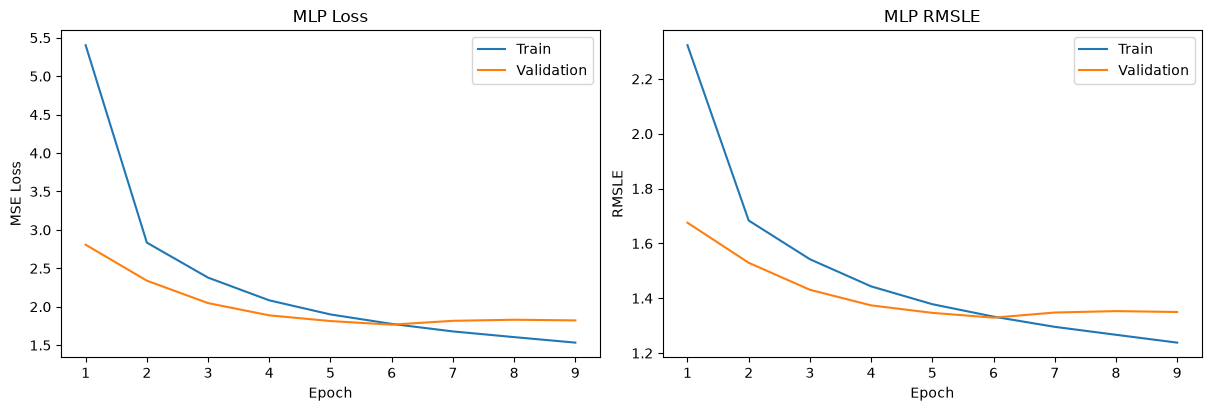

In [215]:
epochs = np.arange(
    1,
    len(history["train_loss"]) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    constrained_layout=True
)


axes[0].plot(
    epochs,
    history["train_loss"],
    label="Train"
)

axes[0].plot(
    epochs,
    history["valid_loss"],
    label="Validation"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "MSE Loss"
)

axes[0].set_title(
    "MLP Loss"
)

axes[0].legend()


axes[1].plot(
    epochs,
    history["train_rmsle"],
    label="Train"
)

axes[1].plot(
    epochs,
    history["valid_rmsle"],
    label="Validation"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "RMSLE"
)

axes[1].set_title(
    "MLP RMSLE"
)

axes[1].legend()

plt.show()

In [216]:
mlp_result = {
    "Model": "MLP",
    "RMSLE": best_valid_rmsle,
    "Train Time (s)": mlp_train_time
}

display(
    pd.DataFrame(
        [mlp_result]
    )
)

,Model,RMSLE,Train Time (s)
0,MLP,1.32918,68.832424


# 12. Blending, stacking

Проверим два способа объединения четырёх моделей: Ridge, LightGBM, XGBoost и MLP.

Для предотвращения data leakage `tuning_train` дополнительно разделяется по времени:

- `ensemble_base_train` — обучение базовых моделей;
- `ensemble_meta_train` — подбор весов blending и обучение meta-model для stacking;
- `tuning_valid` — финальная оценка, не используемая при построении ансамблей.

Подготовка данных

In [220]:
ensemble_features = selected_features

ensemble_model_names = [
    "Ridge",
    "LightGBM",
    "XGBoost",
    "MLP"
]


ensemble_base_train = (
    tuning_train[
        tuning_train["timestamp"] < "2016-10-01"
    ]
    .copy()
)

ensemble_meta_train = (
    tuning_train[
        tuning_train["timestamp"] >= "2016-10-01"
    ]
    .copy()
)


y_ensemble_base = np.log1p(
    ensemble_base_train["meter_reading"]
)

y_ensemble_meta = np.log1p(
    ensemble_meta_train["meter_reading"]
)


print(
    "Base train:",
    len(ensemble_base_train)
)

print(
    "Meta train:",
    len(ensemble_meta_train)
)

print(
    "Final validation:",
    len(tuning_valid)
)

Base train: 301077
Meta train: 34928
Final validation: 168902


Универсальная функция для классических моделей

In [221]:
def fit_predict_classical(
    model_name,
    train_df,
    y_train,
    valid_df,
    features
):

    if model_name == "Ridge":

        model = make_ridge_model(
            features
        )

        model.set_params(
            ridge__alpha=float(
                best_ridge_params[
                    "alpha"
                ]
            )
        )

        X_train = train_df[
            features
        ]

        X_valid = valid_df[
            features
        ]


    elif model_name == "LightGBM":

        model = LGBMRegressor(
            n_estimators=int(
                best_lgbm_params[
                    "n_estimators"
                ]
            ),
            learning_rate=float(
                best_lgbm_params[
                    "learning_rate"
                ]
            ),
            num_leaves=int(
                best_lgbm_params[
                    "num_leaves"
                ]
            ),
            max_depth=int(
                best_lgbm_params[
                    "max_depth"
                ]
            ),
            min_child_samples=int(
                best_lgbm_params[
                    "min_child_samples"
                ]
            ),
            reg_lambda=float(
                best_lgbm_params[
                    "reg_lambda"
                ]
            ),
            n_jobs=-1,
            random_state=SEED,
            verbosity=-1
        )

        X_train = prepare_lgbm_data(
            train_df,
            features
        )

        X_valid = prepare_lgbm_data(
            valid_df,
            features
        )


    elif model_name == "XGBoost":

        model = make_xgb_model(
            features
        )

        model.set_params(
            xgbregressor__n_estimators=int(
                best_xgb_params[
                    "n_estimators"
                ]
            ),
            xgbregressor__learning_rate=float(
                best_xgb_params[
                    "learning_rate"
                ]
            ),
            xgbregressor__max_depth=int(
                best_xgb_params[
                    "max_depth"
                ]
            ),
            xgbregressor__min_child_weight=float(
                best_xgb_params[
                    "min_child_weight"
                ]
            ),
            xgbregressor__subsample=float(
                best_xgb_params[
                    "subsample"
                ]
            ),
            xgbregressor__colsample_bytree=float(
                best_xgb_params[
                    "colsample_bytree"
                ]
            ),
            xgbregressor__reg_lambda=float(
                best_xgb_params[
                    "reg_lambda"
                ]
            )
        )

        X_train = train_df[
            features
        ]

        X_valid = valid_df[
            features
        ]


    start_time = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    train_time = (
        time.perf_counter()
        - start_time
    )


    start_time = time.perf_counter()

    prediction = model.predict(
        X_valid
    )

    predict_time = (
        time.perf_counter()
        - start_time
    )


    return (
        model,
        prediction,
        train_time,
        predict_time
    )

MLP для произвольного train/validation

Для MLP внутри ансамблей используется фиксированное число эпох. Это позволяет получать out-of-sample предсказания для `meta_train`, не используя его target для Early Stopping.

In [223]:
ENSEMBLE_MLP_EPOCHS = 6
ENSEMBLE_BATCH_SIZE = 4096

In [224]:
def fit_predict_mlp(
    train_df,
    y_train,
    valid_df,
    features,
    epochs=ENSEMBLE_MLP_EPOCHS
):

    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


    categorical_features_mlp = [
        feature
        for feature in [
            "building_id",
            "meter",
            "site_id",
            "primary_use"
        ]
        if feature in features
    ]


    numeric_features_mlp = [
        feature
        for feature in features
        if feature not in categorical_features_mlp
    ]


    # Numeric preprocessing
    numeric_preprocessor = make_pipeline(
        SimpleImputer(
            strategy="median"
        ),
        StandardScaler()
    )


    X_num_train = (
        numeric_preprocessor
        .fit_transform(
            train_df[
                numeric_features_mlp
            ]
        )
        .astype(np.float32)
    )


    X_num_valid = (
        numeric_preprocessor
        .transform(
            valid_df[
                numeric_features_mlp
            ]
        )
        .astype(np.float32)
    )


    # Categorical preprocessing
    X_cat_train = []
    X_cat_valid = []

    category_sizes = []


    for feature in categorical_features_mlp:

        train_values = (
            train_df[feature]
            .astype("string")
            .fillna("__MISSING__")
        )

        valid_values = (
            valid_df[feature]
            .astype("string")
            .fillna("__MISSING__")
        )


        categories = (
            train_values
            .unique()
        )


        mapping = {
            value: index + 1
            for index, value
            in enumerate(categories)
        }


        train_codes = (
            train_values
            .map(mapping)
            .fillna(0)
            .astype("int64")
            .to_numpy()
        )

        valid_codes = (
            valid_values
            .map(mapping)
            .fillna(0)
            .astype("int64")
            .to_numpy()
        )


        X_cat_train.append(
            train_codes
        )

        X_cat_valid.append(
            valid_codes
        )

        category_sizes.append(
            len(mapping) + 1
        )


    X_cat_train = np.column_stack(
        X_cat_train
    ).astype(np.int64)

    X_cat_valid = np.column_stack(
        X_cat_valid
    ).astype(np.int64)


    embedding_dims = [
        min(
            32,
            max(
                2,
                int(
                    np.ceil(
                        np.sqrt(size)
                    )
                )
            )
        )
        for size in category_sizes
    ]


    y_train_array = np.asarray(
        y_train,
        dtype=np.float32
    )


    train_dataset_torch = TensorDataset(
        torch.from_numpy(
            X_num_train
        ),
        torch.from_numpy(
            X_cat_train
        ),
        torch.from_numpy(
            y_train_array
        )
    )


    valid_dataset_torch = TensorDataset(
        torch.from_numpy(
            X_num_valid
        ),
        torch.from_numpy(
            X_cat_valid
        )
    )


    train_loader_local = DataLoader(
        train_dataset_torch,
        batch_size=ENSEMBLE_BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )


    valid_loader_local = DataLoader(
        valid_dataset_torch,
        batch_size=ENSEMBLE_BATCH_SIZE,
        shuffle=False
    )


    model = EnergyMLP(
        n_numeric=len(
            numeric_features_mlp
        ),
        category_sizes=category_sizes,
        embedding_dims=embedding_dims
    ).to(DEVICE)


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )

    loss_function = nn.MSELoss()


    start_time = time.perf_counter()


    for epoch in range(
        epochs
    ):

        model.train()


        for (
            numeric,
            categorical,
            target
        ) in train_loader_local:

            numeric = numeric.to(
                DEVICE
            )

            categorical = categorical.to(
                DEVICE
            )

            target = target.to(
                DEVICE
            )


            optimizer.zero_grad()


            prediction = model(
                numeric,
                categorical
            )


            loss = loss_function(
                prediction,
                target
            )


            loss.backward()

            optimizer.step()


    train_time = (
        time.perf_counter()
        - start_time
    )


    # Prediction
    model.eval()

    predictions = []

    start_time = time.perf_counter()


    with torch.no_grad():

        for (
            numeric,
            categorical
        ) in valid_loader_local:

            numeric = numeric.to(
                DEVICE
            )

            categorical = categorical.to(
                DEVICE
            )


            prediction = model(
                numeric,
                categorical
            )


            predictions.append(
                prediction
                .cpu()
                .numpy()
            )


    predict_time = (
        time.perf_counter()
        - start_time
    )


    predictions = np.concatenate(
        predictions
    )


    return (
        model,
        predictions,
        train_time,
        predict_time
    )

### Meta Predictions

Сначала обучим каждую базовую модель только на `ensemble_base_train` и получим её предсказания для более позднего `ensemble_meta_train`.

Эти предсказания используются для настройки blending и stacking.

In [225]:
meta_predictions = {}

In [226]:
for model_name in [
    "Ridge",
    "LightGBM",
    "XGBoost"
]:

    (
        _,
        prediction,
        _,
        _
    ) = fit_predict_classical(
        model_name,
        ensemble_base_train,
        y_ensemble_base,
        ensemble_meta_train,
        ensemble_features
    )


    meta_predictions[
        model_name
    ] = prediction


    print(
        model_name,
        log_rmse(
            y_ensemble_meta,
            prediction
        )
    )

Ridge 1.7259768419625199
LightGBM 1.5077393796085414
XGBoost 1.5151243661124316


MLP meta predictions

In [227]:
(
    _,
    mlp_meta_prediction,
    _,
    _
) = fit_predict_mlp(
    ensemble_base_train,
    y_ensemble_base,
    ensemble_meta_train,
    ensemble_features
)


meta_predictions[
    "MLP"
] = mlp_meta_prediction


print(
    "MLP",
    log_rmse(
        y_ensemble_meta,
        mlp_meta_prediction
    )
)

MLP 1.5473904762273774


## Blending

В blending итоговое предсказание представляет собой взвешенную сумму предсказаний Ridge, LightGBM, XGBoost и MLP.

In [228]:
blend_results = []


for ridge_weight_int in range(11):

    for lgbm_weight_int in range(
        11 - ridge_weight_int
    ):

        for xgb_weight_int in range(
            11
            - ridge_weight_int
            - lgbm_weight_int
        ):

            mlp_weight_int = (
                10
                - ridge_weight_int
                - lgbm_weight_int
                - xgb_weight_int
            )


            weights = np.array([
                ridge_weight_int,
                lgbm_weight_int,
                xgb_weight_int,
                mlp_weight_int
            ]) / 10


            prediction = (
                weights[0]
                * meta_predictions[
                    "Ridge"
                ]
                +
                weights[1]
                * meta_predictions[
                    "LightGBM"
                ]
                +
                weights[2]
                * meta_predictions[
                    "XGBoost"
                ]
                +
                weights[3]
                * meta_predictions[
                    "MLP"
                ]
            )


            score = log_rmse(
                y_ensemble_meta,
                prediction
            )


            blend_results.append({
                "Ridge": weights[0],
                "LightGBM": weights[1],
                "XGBoost": weights[2],
                "MLP": weights[3],
                "RMSLE": score
            })

лучший blend

In [229]:
blend_df = (
    pd.DataFrame(
        blend_results
    )
    .sort_values(
        "RMSLE"
    )
    .reset_index(
        drop=True
    )
)


display(
    blend_df.head(10)
)


best_blend_weights = (
    blend_df
    .iloc[0]
)


print(
    "Best weights:"
)

print(
    best_blend_weights
)

,Ridge,LightGBM,XGBoost,MLP,RMSLE
0,0.0,0.4,0.3,0.3,1.484851
1,0.1,0.4,0.3,0.2,1.484907
2,0.1,0.3,0.4,0.2,1.485272
3,0.0,0.3,0.4,0.3,1.485347
4,0.0,0.5,0.2,0.3,1.485514
5,0.1,0.5,0.2,0.2,1.485706
6,0.0,0.3,0.3,0.4,1.485911
7,0.0,0.4,0.2,0.4,1.486063
8,0.1,0.3,0.3,0.3,1.486093
9,0.1,0.4,0.2,0.3,1.486371


Best weights:
Ridge       0.000000
LightGBM    0.400000
XGBoost     0.300000
MLP         0.300000
RMSLE       1.484851
Name: 0, dtype: float64


## Stacking

В stacking предсказания Ridge, LightGBM, XGBoost и MLP используются как четыре новых признака.

На out-of-sample предсказаниях `ensemble_meta_train` обучается линейная meta-model Ridge Regression, которая самостоятельно определяет оптимальный способ объединения базовых моделей.

In [230]:
X_stack_meta = np.column_stack([
    meta_predictions[
        "Ridge"
    ],
    meta_predictions[
        "LightGBM"
    ],
    meta_predictions[
        "XGBoost"
    ],
    meta_predictions[
        "MLP"
    ]
])


stack_meta_model = Ridge(
    alpha=1.0
)


stack_meta_model.fit(
    X_stack_meta,
    y_ensemble_meta
)


print(
    "Stacking coefficients:"
)


for model_name, coef in zip(
    ensemble_model_names,
    stack_meta_model.coef_
):

    print(
        f"{model_name}: "
        f"{coef:.4f}"
    )

Stacking coefficients:
Ridge: -0.0537
LightGBM: 0.4377
XGBoost: 0.2570
MLP: 0.2527


## Final Validation Predictions

После настройки ансамблей базовые модели переобучаются на всём `tuning_train`.

Окончательное качество standalone-моделей, blending и stacking сравнивается на одном и том же `tuning_valid`.

In [231]:
final_predictions = {}

final_train_times = {}

final_predict_times = {}

comparison_results = []

In [232]:
for model_name in [
    "Ridge",
    "LightGBM",
    "XGBoost"
]:

    (
        model,
        prediction,
        train_time,
        predict_time
    ) = fit_predict_classical(
        model_name,
        tuning_train,
        y_tuning_train,
        tuning_valid,
        ensemble_features
    )


    final_predictions[
        model_name
    ] = prediction

    final_train_times[
        model_name
    ] = train_time

    final_predict_times[
        model_name
    ] = predict_time


    score = log_rmse(
        y_tuning_valid,
        prediction
    )


    comparison_results.append({
        "Model": model_name,
        "RMSLE": score,
        "Train Time (s)": train_time,
        "Predict Time (s)": predict_time
    })


    print(
        f"{model_name}: "
        f"{score:.5f}"
    )

Ridge: 1.55754
LightGBM: 1.34997
XGBoost: 1.37904


In [233]:
(
    final_mlp_model,
    final_mlp_prediction,
    final_mlp_train_time,
    final_mlp_predict_time
) = fit_predict_mlp(
    tuning_train,
    y_tuning_train,
    tuning_valid,
    ensemble_features
)


final_predictions[
    "MLP"
] = final_mlp_prediction

final_train_times[
    "MLP"
] = final_mlp_train_time

final_predict_times[
    "MLP"
] = final_mlp_predict_time


final_mlp_score = log_rmse(
    y_tuning_valid,
    final_mlp_prediction
)


comparison_results.append({
    "Model": "MLP",
    "RMSLE": final_mlp_score,
    "Train Time (s)": final_mlp_train_time,
    "Predict Time (s)": final_mlp_predict_time
})


print(
    f"MLP: "
    f"{final_mlp_score:.5f}"
)

MLP: 1.34341


Проверяем Blending

In [234]:
blend_prediction = (
    best_blend_weights["Ridge"]
    * final_predictions["Ridge"]

    + best_blend_weights["LightGBM"]
    * final_predictions["LightGBM"]

    + best_blend_weights["XGBoost"]
    * final_predictions["XGBoost"]

    + best_blend_weights["MLP"]
    * final_predictions["MLP"]
)


blend_score = log_rmse(
    y_tuning_valid,
    blend_prediction
)


ensemble_base_train_time = sum(
    final_train_times.values()
)

ensemble_base_predict_time = sum(
    final_predict_times.values()
)


comparison_results.append({
    "Model": "Blending",
    "RMSLE": blend_score,
    "Train Time (s)": ensemble_base_train_time,
    "Predict Time (s)": ensemble_base_predict_time
})


print(
    f"Blending: "
    f"{blend_score:.5f}"
)

Blending: 1.31731


Проверяем Stacking

In [235]:
X_stack_valid = np.column_stack([
    final_predictions[
        "Ridge"
    ],
    final_predictions[
        "LightGBM"
    ],
    final_predictions[
        "XGBoost"
    ],
    final_predictions[
        "MLP"
    ]
])


start_time = time.perf_counter()


stack_prediction = (
    stack_meta_model
    .predict(
        X_stack_valid
    )
)


stack_predict_time = (
    time.perf_counter()
    - start_time
)


stack_score = log_rmse(
    y_tuning_valid,
    stack_prediction
)


comparison_results.append({
    "Model": "Stacking",
    "RMSLE": stack_score,
    "Train Time (s)": ensemble_base_train_time,
    "Predict Time (s)": (
        ensemble_base_predict_time
        + stack_predict_time
    )
})


print(
    f"Stacking: "
    f"{stack_score:.5f}"
)

Stacking: 1.31299


# 13. Final Model Comparison

In [236]:
dummy_model = DummyRegressor(
    strategy="mean"
)


start_time = time.perf_counter()

dummy_model.fit(
    tuning_train[
        ensemble_features
    ],
    y_tuning_train
)

dummy_train_time = (
    time.perf_counter()
    - start_time
)


start_time = time.perf_counter()

dummy_prediction = (
    dummy_model.predict(
        tuning_valid[
            ensemble_features
        ]
    )
)

dummy_predict_time = (
    time.perf_counter()
    - start_time
)


comparison_results.append({
    "Model": "Dummy",
    "RMSLE": log_rmse(
        y_tuning_valid,
        dummy_prediction
    ),
    "Train Time (s)": dummy_train_time,
    "Predict Time (s)": dummy_predict_time
})

In [237]:
tree_model = make_decision_tree_model(
    ensemble_features
)


start_time = time.perf_counter()

tree_model.fit(
    tuning_train[
        ensemble_features
    ],
    y_tuning_train
)

tree_train_time = (
    time.perf_counter()
    - start_time
)


start_time = time.perf_counter()

tree_prediction = (
    tree_model.predict(
        tuning_valid[
            ensemble_features
        ]
    )
)

tree_predict_time = (
    time.perf_counter()
    - start_time
)


comparison_results.append({
    "Model": "DecisionTree",
    "RMSLE": log_rmse(
        y_tuning_valid,
        tree_prediction
    ),
    "Train Time (s)": tree_train_time,
    "Predict Time (s)": tree_predict_time
})

## Итоговая таблица

In [238]:
final_comparison_df = (
    pd.DataFrame(
        comparison_results
    )
    .sort_values(
        "RMSLE"
    )
    .reset_index(
        drop=True
    )
)


display(
    final_comparison_df
)

,Model,RMSLE,Train Time (s),Predict Time (s)
0,Stacking,1.312985,60.681088,5.125037
1,Blending,1.317309,60.681088,5.121753
2,MLP,1.343406,36.399427,1.953988
3,LightGBM,1.349973,9.097888,2.062142
4,XGBoost,1.379042,11.006070,0.815334
5,Ridge,1.557539,4.177702,0.290289
6,DecisionTree,1.630894,4.285093,0.180674
7,Dummy,2.036239,0.002115,0.001108


# 14. Final training on the entire dataset and prediction.

По результатам предыдущих экспериментов лучшим подходом оказался stacking из Ridge, LightGBM, XGBoost и MLP.

Meta-model stacking была обучена на out-of-sample предсказаниях отдельного временного периода. В финальном этапе базовые модели переобучаются на всём доступном train-датасете, после чего их предсказания для test объединяются ранее обученной meta-model.

Такой подход позволяет использовать все доступные обучающие данные для базовых моделей и при этом избежать leakage при обучении meta-model.

In [240]:
final_features = selected_features

y_full = np.log1p(
    train_features["meter_reading"]
)

FINAL_TEST_CHUNK_SIZE = 500_000

print(
    "Train rows:",
    len(train_features)
)

print(
    "Test rows:",
    len(test_features)
)

print(
    "Features:",
    len(final_features)
)

Train rows: 20216100
Test rows: 41697600
Features: 17


Поскольку test содержит более 40 млн строк, предсказания выполняются по частям (`chunks`), чтобы уменьшить потребление оперативной памяти.

Stacking является линейной meta-model, поэтому итоговое предсказание можно накапливать последовательно, не сохраняя одновременно предсказания всех четырёх базовых моделей.

Инициализируем итоговый stacking prediction

In [241]:
stack_model_names = [
    "Ridge",
    "LightGBM",
    "XGBoost",
    "MLP"
]

stack_coefficients = dict(
    zip(
        stack_model_names,
        stack_meta_model.coef_
    )
)

print(
    "Stacking coefficients:"
)

for name, coefficient in (
    stack_coefficients.items()
):
    print(
        f"{name}: "
        f"{coefficient:.4f}"
    )

print(
    "Intercept:",
    stack_meta_model.intercept_
)

Stacking coefficients:
Ridge: -0.0537
LightGBM: 0.4377
XGBoost: 0.2570
MLP: 0.2527
Intercept: 0.42092762052762644


In [242]:
stack_test_log_prediction = np.full(
    len(test_features),
    float(
        stack_meta_model.intercept_
    ),
    dtype=np.float32
)

## 14.1 Final Ridge

Обучим Ridge с найденным значением `alpha` на всём train-датасете и добавим его вклад в stacking prediction.

In [243]:
final_ridge = make_ridge_model(
    final_features
)

final_ridge.set_params(
    ridge__alpha=float(
        best_ridge_params["alpha"]
    )
)


final_ridge.fit(
    train_features[
        final_features
    ],
    y_full
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [244]:
ridge_coef = (
    stack_coefficients["Ridge"]
)


for start in range(
    0,
    len(test_features),
    FINAL_TEST_CHUNK_SIZE
):

    end = min(
        start + FINAL_TEST_CHUNK_SIZE,
        len(test_features)
    )

    chunk = test_features.iloc[
        start:end
    ]

    prediction = final_ridge.predict(
        chunk[
            final_features
        ]
    )

    stack_test_log_prediction[
        start:end
    ] += (
        ridge_coef
        * prediction.astype(
            np.float32
        )
    )


    print(
        f"Ridge: "
        f"{end:,}/"
        f"{len(test_features):,}"
    )

Ridge: 500,000/41,697,600
Ridge: 1,000,000/41,697,600
Ridge: 1,500,000/41,697,600
Ridge: 2,000,000/41,697,600
Ridge: 2,500,000/41,697,600
Ridge: 3,000,000/41,697,600
Ridge: 3,500,000/41,697,600
Ridge: 4,000,000/41,697,600
Ridge: 4,500,000/41,697,600
Ridge: 5,000,000/41,697,600
Ridge: 5,500,000/41,697,600
Ridge: 6,000,000/41,697,600
Ridge: 6,500,000/41,697,600
Ridge: 7,000,000/41,697,600
Ridge: 7,500,000/41,697,600
Ridge: 8,000,000/41,697,600
Ridge: 8,500,000/41,697,600
Ridge: 9,000,000/41,697,600
Ridge: 9,500,000/41,697,600
Ridge: 10,000,000/41,697,600
Ridge: 10,500,000/41,697,600
Ridge: 11,000,000/41,697,600
Ridge: 11,500,000/41,697,600
Ridge: 12,000,000/41,697,600
Ridge: 12,500,000/41,697,600
Ridge: 13,000,000/41,697,600
Ridge: 13,500,000/41,697,600
Ridge: 14,000,000/41,697,600
Ridge: 14,500,000/41,697,600
Ridge: 15,000,000/41,697,600
Ridge: 15,500,000/41,697,600
Ridge: 16,000,000/41,697,600
Ridge: 16,500,000/41,697,600
Ridge: 17,000,000/41,697,600
Ridge: 17,500,000/41,697,600
Ridge:

In [245]:
del final_ridge
gc.collect()

524

## 14.2 Final LightGBM

In [246]:
final_lgbm = LGBMRegressor(
    n_estimators=int(
        best_lgbm_params[
            "n_estimators"
        ]
    ),

    learning_rate=float(
        best_lgbm_params[
            "learning_rate"
        ]
    ),

    num_leaves=int(
        best_lgbm_params[
            "num_leaves"
        ]
    ),

    max_depth=int(
        best_lgbm_params[
            "max_depth"
        ]
    ),

    min_child_samples=int(
        best_lgbm_params[
            "min_child_samples"
        ]
    ),

    reg_lambda=float(
        best_lgbm_params[
            "reg_lambda"
        ]
    ),

    n_jobs=-1,
    random_state=SEED,
    verbosity=-1
)

In [247]:
X_full_lgbm = prepare_lgbm_data(
    train_features,
    final_features
)

final_lgbm.fit(
    X_full_lgbm,
    y_full
)

del X_full_lgbm
gc.collect()

48

In [248]:
lgbm_coef = (
    stack_coefficients[
        "LightGBM"
    ]
)


for start in range(
    0,
    len(test_features),
    FINAL_TEST_CHUNK_SIZE
):

    end = min(
        start + FINAL_TEST_CHUNK_SIZE,
        len(test_features)
    )

    chunk = test_features.iloc[
        start:end
    ]

    X_chunk = prepare_lgbm_data(
        chunk,
        final_features
    )

    prediction = (
        final_lgbm.predict(
            X_chunk
        )
    )

    stack_test_log_prediction[
        start:end
    ] += (
        lgbm_coef
        * prediction.astype(
            np.float32
        )
    )

    del X_chunk

    print(
        f"LightGBM: "
        f"{end:,}/"
        f"{len(test_features):,}"
    )

LightGBM: 500,000/41,697,600
LightGBM: 1,000,000/41,697,600
LightGBM: 1,500,000/41,697,600
LightGBM: 2,000,000/41,697,600
LightGBM: 2,500,000/41,697,600
LightGBM: 3,000,000/41,697,600
LightGBM: 3,500,000/41,697,600
LightGBM: 4,000,000/41,697,600
LightGBM: 4,500,000/41,697,600
LightGBM: 5,000,000/41,697,600
LightGBM: 5,500,000/41,697,600
LightGBM: 6,000,000/41,697,600
LightGBM: 6,500,000/41,697,600
LightGBM: 7,000,000/41,697,600
LightGBM: 7,500,000/41,697,600
LightGBM: 8,000,000/41,697,600
LightGBM: 8,500,000/41,697,600
LightGBM: 9,000,000/41,697,600
LightGBM: 9,500,000/41,697,600
LightGBM: 10,000,000/41,697,600
LightGBM: 10,500,000/41,697,600
LightGBM: 11,000,000/41,697,600
LightGBM: 11,500,000/41,697,600
LightGBM: 12,000,000/41,697,600
LightGBM: 12,500,000/41,697,600
LightGBM: 13,000,000/41,697,600
LightGBM: 13,500,000/41,697,600
LightGBM: 14,000,000/41,697,600
LightGBM: 14,500,000/41,697,600
LightGBM: 15,000,000/41,697,600
LightGBM: 15,500,000/41,697,600
LightGBM: 16,000,000/41,697,6

In [249]:
del final_lgbm
gc.collect()

32

## 14.3 Final XGBoost

In [250]:
final_xgb = make_xgb_model(
    final_features
)


final_xgb.set_params(

    xgbregressor__n_estimators=int(
        best_xgb_params[
            "n_estimators"
        ]
    ),

    xgbregressor__learning_rate=float(
        best_xgb_params[
            "learning_rate"
        ]
    ),

    xgbregressor__max_depth=int(
        best_xgb_params[
            "max_depth"
        ]
    ),

    xgbregressor__min_child_weight=float(
        best_xgb_params[
            "min_child_weight"
        ]
    ),

    xgbregressor__subsample=float(
        best_xgb_params[
            "subsample"
        ]
    ),

    xgbregressor__colsample_bytree=float(
        best_xgb_params[
            "colsample_bytree"
        ]
    ),

    xgbregressor__reg_lambda=float(
        best_xgb_params[
            "reg_lambda"
        ]
    )
)


final_xgb.fit(
    train_features[
        final_features
    ],
    y_full
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [251]:
xgb_coef = (
    stack_coefficients[
        "XGBoost"
    ]
)


for start in range(
    0,
    len(test_features),
    FINAL_TEST_CHUNK_SIZE
):

    end = min(
        start + FINAL_TEST_CHUNK_SIZE,
        len(test_features)
    )

    chunk = test_features.iloc[
        start:end
    ]

    prediction = final_xgb.predict(
        chunk[
            final_features
        ]
    )

    stack_test_log_prediction[
        start:end
    ] += (
        xgb_coef
        * prediction.astype(
            np.float32
        )
    )


    print(
        f"XGBoost: "
        f"{end:,}/"
        f"{len(test_features):,}"
    )

XGBoost: 500,000/41,697,600
XGBoost: 1,000,000/41,697,600
XGBoost: 1,500,000/41,697,600
XGBoost: 2,000,000/41,697,600
XGBoost: 2,500,000/41,697,600
XGBoost: 3,000,000/41,697,600
XGBoost: 3,500,000/41,697,600
XGBoost: 4,000,000/41,697,600
XGBoost: 4,500,000/41,697,600
XGBoost: 5,000,000/41,697,600
XGBoost: 5,500,000/41,697,600
XGBoost: 6,000,000/41,697,600
XGBoost: 6,500,000/41,697,600
XGBoost: 7,000,000/41,697,600
XGBoost: 7,500,000/41,697,600
XGBoost: 8,000,000/41,697,600
XGBoost: 8,500,000/41,697,600
XGBoost: 9,000,000/41,697,600
XGBoost: 9,500,000/41,697,600
XGBoost: 10,000,000/41,697,600
XGBoost: 10,500,000/41,697,600
XGBoost: 11,000,000/41,697,600
XGBoost: 11,500,000/41,697,600
XGBoost: 12,000,000/41,697,600
XGBoost: 12,500,000/41,697,600
XGBoost: 13,000,000/41,697,600
XGBoost: 13,500,000/41,697,600
XGBoost: 14,000,000/41,697,600
XGBoost: 14,500,000/41,697,600
XGBoost: 15,000,000/41,697,600
XGBoost: 15,500,000/41,697,600
XGBoost: 16,000,000/41,697,600
XGBoost: 16,500,000/41,697,60

In [252]:
del final_xgb
gc.collect()

309

## 14.4 Final MLP

MLP обучается на всём train в течение фиксированного числа эпох. Количество эпох выбрано на основании предыдущего validation-эксперимента.

Для test предсказания также вычисляются по частям.

In [253]:
FINAL_MLP_EPOCHS = 6
FINAL_MLP_BATCH_SIZE = 4096


final_mlp_categorical = [
    feature
    for feature in [
        "building_id",
        "meter",
        "site_id",
        "primary_use"
    ]
    if feature in final_features
]


final_mlp_numeric = [
    feature
    for feature in final_features
    if feature
    not in final_mlp_categorical
]

In [255]:
final_numeric_preprocessor = make_pipeline(
    SimpleImputer(
        strategy="median"
    ),
    StandardScaler()
)

X_num_full = (
    final_numeric_preprocessor
    .fit_transform(
        train_features[
            final_mlp_numeric
        ]
    )
    .astype(np.float32)
)

In [256]:
final_category_maps = {}

X_cat_full = []

final_category_sizes = []


for feature in final_mlp_categorical:

    values = (
        train_features[
            feature
        ]
        .astype("string")
        .fillna("__MISSING__")
    )


    categories = (
        values.unique()
    )


    mapping = {
        value: index + 1
        for index, value
        in enumerate(categories)
    }


    final_category_maps[
        feature
    ] = mapping


    codes = (
        values
        .map(mapping)
        .fillna(0)
        .astype("int32")
        .to_numpy()
    )


    X_cat_full.append(
        codes
    )


    final_category_sizes.append(
        len(mapping) + 1
    )


X_cat_full = (
    np.column_stack(
        X_cat_full
    )
    .astype(
        np.int32
    )
)

In [257]:
final_embedding_dims = [
    min(
        32,
        max(
            2,
            int(
                np.ceil(
                    np.sqrt(size)
                )
            )
        )
    )
    for size
    in final_category_sizes
]

In [258]:
y_full_array = (
    y_full
    .to_numpy(
        dtype=np.float32
    )
)


final_mlp_dataset = (
    TensorDataset(

        torch.from_numpy(
            X_num_full
        ),

        torch.from_numpy(
            X_cat_full
        ),

        torch.from_numpy(
            y_full_array
        )
    )
)


final_mlp_loader = DataLoader(
    final_mlp_dataset,
    batch_size=FINAL_MLP_BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [259]:
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


final_mlp = EnergyMLP(
    n_numeric=len(
        final_mlp_numeric
    ),

    category_sizes=(
        final_category_sizes
    ),

    embedding_dims=(
        final_embedding_dims
    )
).to(DEVICE)


final_mlp_optimizer = (
    torch.optim.AdamW(
        final_mlp.parameters(),
        lr=1e-3,
        weight_decay=1e-4
    )
)


final_mlp_criterion = (
    nn.MSELoss()
)

In [260]:
for epoch in range(
    1,
    FINAL_MLP_EPOCHS + 1
):

    final_mlp.train()

    total_loss = 0.0
    total_samples = 0


    for (
        numeric,
        categorical,
        target
    ) in final_mlp_loader:

        numeric = numeric.to(
            DEVICE
        )

        categorical = categorical.to(
            DEVICE,
            dtype=torch.long
        )

        target = target.to(
            DEVICE
        )


        final_mlp_optimizer.zero_grad()


        prediction = final_mlp(
            numeric,
            categorical
        )


        loss = final_mlp_criterion(
            prediction,
            target
        )


        loss.backward()

        final_mlp_optimizer.step()


        batch_size = target.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += batch_size


    print(
        f"Epoch {epoch:02d} | "
        f"Loss: "
        f"{total_loss / total_samples:.5f}"
    )

Epoch 01 | Loss: 1.41077
Epoch 02 | Loss: 1.06188
Epoch 03 | Loss: 0.99983
Epoch 04 | Loss: 0.96343
Epoch 05 | Loss: 0.94145
Epoch 06 | Loss: 0.92458


In [261]:
del X_num_full
del X_cat_full
del y_full_array
del final_mlp_dataset
del final_mlp_loader

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [262]:
mlp_coef = (
    stack_coefficients["MLP"]
)

final_mlp.eval()


for start in range(
    0,
    len(test_features),
    FINAL_TEST_CHUNK_SIZE
):

    end = min(
        start + FINAL_TEST_CHUNK_SIZE,
        len(test_features)
    )


    chunk = test_features.iloc[
        start:end
    ]


    X_num_chunk = (
        final_numeric_preprocessor
        .transform(
            chunk[
                final_mlp_numeric
            ]
        )
        .astype(
            np.float32
        )
    )


    X_cat_chunk = []


    for feature in (
        final_mlp_categorical
    ):

        mapping = (
            final_category_maps[
                feature
            ]
        )


        codes = (
            chunk[feature]
            .astype("string")
            .fillna("__MISSING__")
            .map(mapping)
            .fillna(0)
            .astype("int64")
            .to_numpy()
        )


        X_cat_chunk.append(
            codes
        )


    X_cat_chunk = (
        np.column_stack(
            X_cat_chunk
        )
        .astype(
            np.int64
        )
    )


    chunk_dataset = TensorDataset(

        torch.from_numpy(
            X_num_chunk
        ),

        torch.from_numpy(
            X_cat_chunk
        )
    )


    chunk_loader = DataLoader(
        chunk_dataset,
        batch_size=FINAL_MLP_BATCH_SIZE,
        shuffle=False
    )


    chunk_predictions = []


    with torch.no_grad():

        for (
            numeric,
            categorical
        ) in chunk_loader:

            numeric = numeric.to(
                DEVICE
            )

            categorical = (
                categorical.to(
                    DEVICE,
                    dtype=torch.long
                )
            )


            prediction = final_mlp(
                numeric,
                categorical
            )


            chunk_predictions.append(
                prediction
                .cpu()
                .numpy()
            )


    chunk_predictions = (
        np.concatenate(
            chunk_predictions
        )
    )


    stack_test_log_prediction[
        start:end
    ] += (
        mlp_coef
        * chunk_predictions.astype(
            np.float32
        )
    )


    print(
        f"MLP: "
        f"{end:,}/"
        f"{len(test_features):,}"
    )


    del X_num_chunk
    del X_cat_chunk
    del chunk_dataset
    del chunk_loader
    del chunk_predictions

    gc.collect()

MLP: 500,000/41,697,600
MLP: 1,000,000/41,697,600
MLP: 1,500,000/41,697,600
MLP: 2,000,000/41,697,600
MLP: 2,500,000/41,697,600
MLP: 3,000,000/41,697,600
MLP: 3,500,000/41,697,600
MLP: 4,000,000/41,697,600
MLP: 4,500,000/41,697,600
MLP: 5,000,000/41,697,600
MLP: 5,500,000/41,697,600
MLP: 6,000,000/41,697,600
MLP: 6,500,000/41,697,600
MLP: 7,000,000/41,697,600
MLP: 7,500,000/41,697,600
MLP: 8,000,000/41,697,600
MLP: 8,500,000/41,697,600
MLP: 9,000,000/41,697,600
MLP: 9,500,000/41,697,600
MLP: 10,000,000/41,697,600
MLP: 10,500,000/41,697,600
MLP: 11,000,000/41,697,600
MLP: 11,500,000/41,697,600
MLP: 12,000,000/41,697,600
MLP: 12,500,000/41,697,600
MLP: 13,000,000/41,697,600
MLP: 13,500,000/41,697,600
MLP: 14,000,000/41,697,600
MLP: 14,500,000/41,697,600
MLP: 15,000,000/41,697,600
MLP: 15,500,000/41,697,600
MLP: 16,000,000/41,697,600
MLP: 16,500,000/41,697,600
MLP: 17,000,000/41,697,600
MLP: 17,500,000/41,697,600
MLP: 18,000,000/41,697,600
MLP: 18,500,000/41,697,600
MLP: 19,000,000/41,697

## 14.5 Submission

Все четыре базовые модели предсказывают логарифм целевой переменной. Stacking meta-model также формирует предсказание в логарифмическом пространстве.

Для получения исходного `meter_reading` применяется обратное преобразование `expm1`. Отрицательные значения обрезаются до нуля.

In [263]:
test_prediction = np.expm1(
    stack_test_log_prediction
)

test_prediction = np.clip(
    test_prediction,
    0,
    None
)

In [264]:
print(
    "Min prediction:",
    test_prediction.min()
)

print(
    "Max prediction:",
    test_prediction.max()
)

print(
    "NaN:",
    np.isnan(
        test_prediction
    ).sum()
)

print(
    "Inf:",
    np.isinf(
        test_prediction
    ).sum()
)

Min prediction: 0.0
Max prediction: 189523.61
NaN: 0
Inf: 0


In [265]:
submission = pd.DataFrame({
    "row_id": (
        test_features[
            "row_id"
        ]
        .to_numpy()
    ),

    "meter_reading": (
        test_prediction
    )
})


submission = (
    submission
    .sort_values(
        "row_id"
    )
    .reset_index(
        drop=True
    )
)


display(
    submission.head()
)

print(
    submission.shape
)

,row_id,meter_reading
0,0,5.695185
1,1,3.567799
2,2,1.796088
3,3,6.813505
4,4,10.175247


(41697600, 2)


In [266]:
submission.to_csv(
    "submission.csv",
    index=False
)

# Итог

### Final Result

Финальная модель представляет собой stacking Ridge, LightGBM, XGBoost и MLP.

Базовые модели были переобучены на всём доступном train-датасете с выбранными признаками и найденными ранее гиперпараметрами. Их test-предсказания были объединены meta-model Ridge, обученной на out-of-sample предсказаниях временного holdout.

Итоговые предсказания были преобразованы обратно из `log1p` пространства.

Private Score 1.371

Public Score 1.251






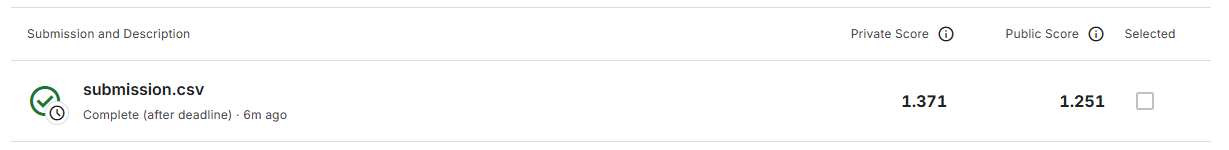